# Regresi Aktivitas Radionuklida

Memprediksi **nilai aktivitas (ternormalisasi [0,1])** untuk 4 isotop (Co-60, Cs-137, Ra-226, Eu-152) dari spektrum gamma 1024-channel.

Output adalah **multi-output regression** dengan 4 nilai kontinyu. Sampel yang tidak memiliki isotop tertentu memiliki aktivitas 0 untuk isotop tersebut.

## Model yang Dibandingkan

| # | Model | Tipe | Hyperparameter Tuning |
|---|-------|------|----------------------|
| 1 | **Hybrid CNN-LSTM** (utama) | Deep Learning | Optuna |
| 2 | CNN 1D | Deep Learning | Optuna |
| 3 | MLP (Fully Connected) | Deep Learning | Optuna |
| 4 | Random Forest Regressor | Classical | Optuna |
| 5 | XGBoost Regressor | Gradient Boosting | Optuna |

## Metrik

- MAE, RMSE, R² — keseluruhan dan per isotop
- Optimasi tuning: **MAE** rata-rata (lebih robust terhadap outlier)

## 1. Setup & Konfigurasi

In [1]:
import os, json, time, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

BASE_DIR    = r"C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)"
DATA_NPZ    = os.path.join(BASE_DIR, "DATA SPLIT.npz")
RESULTS_DIR = os.path.join(BASE_DIR, "results_regresi")
MODELS_DIR  = os.path.join(BASE_DIR, "models_regresi")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

SEED       = 42
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_EPOCHS = 40
PATIENCE   = 7

# Trials per model (100 untuk semua, feasible dengan GPU)
N_TRIALS_PER_MODEL = {
    'CNN-LSTM'    : 100,
    'CNN'         : 100,
    'MLP'         : 100,
    'RandomForest': 100,
    'XGBoost'     : 100,
}

torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

print(f"PyTorch     : {torch.__version__}")
print(f"Device      : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"MAX_EPOCHS  : {MAX_EPOCHS}")
print(f"N_TRIALS    :")
for k, v in N_TRIALS_PER_MODEL.items():
    print(f"  {k:<15s}: {v}")
print(f"\nDATA_NPZ    : {DATA_NPZ}")
print(f"  exists?   : {os.path.isfile(DATA_NPZ)}")

PyTorch     : 2.6.0+cu124
Device      : cuda
GPU         : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM        : 6.4 GB
MAX_EPOCHS  : 40
N_TRIALS    :
  CNN-LSTM       : 100
  CNN            : 100
  MLP            : 100
  RandomForest   : 100
  XGBoost        : 100

DATA_NPZ    : C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)\DATA SPLIT.npz
  exists?   : True


## 2. Load Data

In [2]:
data = np.load(DATA_NPZ, allow_pickle=True)
X_train, y_train = data['X_train'], data['y_reg_train']
X_val,   y_val   = data['X_val'],   data['y_reg_val']
X_test,  y_test  = data['X_test'],  data['y_reg_test']
ISOTOP = list(data['isotop_names'])

print(f"Train : X={X_train.shape}, y={y_train.shape}")
print(f"Val   : X={X_val.shape}, y={y_val.shape}")
print(f"Test  : X={X_test.shape}, y={y_test.shape}")

print(f"\nStatistik aktivitas per isotop (train):")
for i, iso in enumerate(ISOTOP):
    v = y_train[:, i]
    nz = v[v > 0]
    print(f"  {iso:<8s}: n_positive={len(nz):4d}, mean_pos={nz.mean():.3f}, max={v.max():.3f}")

Train : X=(2560, 1024), y=(2560, 4)
Val   : X=(320, 1024), y=(320, 4)
Test  : X=(320, 1024), y=(320, 4)

Statistik aktivitas per isotop (train):
  Co-60   : n_positive=1340, mean_pos=0.504, max=1.000
  Cs-137  : n_positive=1340, mean_pos=0.640, max=1.000
  Ra-226  : n_positive=1340, mean_pos=0.586, max=1.000
  Eu-152  : n_positive=1340, mean_pos=0.526, max=0.965


## 3. Helper Functions

In [3]:
def compute_metrics_reg(y_true, y_pred):
    """Hitung metrik regresi (keseluruhan + per isotop)."""
    m = {
        'mae'  : mean_absolute_error(y_true, y_pred),
        'rmse' : np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2'   : r2_score(y_true, y_pred, multioutput='uniform_average'),
    }
    for i, iso in enumerate(ISOTOP):
        m[f'mae_{iso}']  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        m[f'rmse_{iso}'] = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        m[f'r2_{iso}']   = r2_score(y_true[:, i], y_pred[:, i])
    return m


def train_torch_reg(model, X_train, y_train, X_val, y_val,
                    batch_size, lr, optimizer_name='adam', loss_type='mse',
                    max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """Train regressor PyTorch dengan early stopping berdasarkan val MAE."""
    model = model.to(DEVICE)
    Xt = torch.tensor(X_train, dtype=torch.float32)
    yt = torch.tensor(y_train, dtype=torch.float32)
    Xv = torch.tensor(X_val,   dtype=torch.float32).to(DEVICE)
    yv = torch.tensor(y_val,   dtype=torch.float32).to(DEVICE)
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True)
    
    if optimizer_name == 'adam':
        opt = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'adamw':
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    else:
        opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    loss_fn = nn.L1Loss() if loss_type == 'mae' else nn.MSELoss()
    best_val = float('inf')
    best_state = None
    wait = 0
    
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
        
        model.eval()
        with torch.no_grad():
            vp = model(Xv)
            val_mae = (vp - yv).abs().mean().item()
        
        if val_mae < best_val - 1e-6:
            best_val = val_mae
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_val


def predict_torch_reg(model, X, batch_size=256):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(DEVICE)
            preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds, axis=0)

print('Helpers defined.')

Helpers defined.


## 4. Definisi Arsitektur Model

In [4]:
class CNN_LSTM_Reg(nn.Module):
    def __init__(self, n_filters=32, kernel_size=5, n_conv=2, lstm_hidden=64,
                 bidirectional=True, dropout=0.3, n_outputs=4):
        super().__init__()
        convs = []
        in_ch = 1
        for i in range(n_conv):
            out_ch = n_filters * (2 ** i)
            convs += [nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size//2),
                      nn.BatchNorm1d(out_ch), nn.ReLU(), nn.MaxPool1d(2)]
            in_ch = out_ch
        self.conv = nn.Sequential(*convs)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm = nn.LSTM(in_ch, lstm_hidden, batch_first=True, bidirectional=bidirectional)
        lstm_out = lstm_hidden * (2 if bidirectional else 1)
        self.dropout2 = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_out, n_outputs)
    
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = self.dropout1(x)
        x = x.transpose(1, 2)
        _, (h, _) = self.lstm(x)
        if self.lstm.bidirectional:
            h = torch.cat([h[-2], h[-1]], dim=-1)
        else:
            h = h[-1]
        h = self.dropout2(h)
        # Output [0, 1] via sigmoid
        return torch.sigmoid(self.fc(h))


class CNN_Reg(nn.Module):
    def __init__(self, n_filters=32, kernel_size=5, n_conv=3, fc_hidden=64,
                 dropout=0.3, n_outputs=4):
        super().__init__()
        convs = []
        in_ch = 1
        for i in range(n_conv):
            out_ch = n_filters * (2 ** i)
            convs += [nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size//2),
                      nn.BatchNorm1d(out_ch), nn.ReLU(), nn.MaxPool1d(2)]
            in_ch = out_ch
        self.conv = nn.Sequential(*convs)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(in_ch, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, n_outputs)
    
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = self.pool(x).squeeze(-1)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(x))


class MLP_Reg(nn.Module):
    def __init__(self, hidden_layers=[256, 128], dropout=0.3, n_inputs=1024, n_outputs=4):
        super().__init__()
        layers = []
        prev = n_inputs
        for h in hidden_layers:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_outputs))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return torch.sigmoid(self.net(x))

# Smoke test
x_test = torch.randn(4, 1024)
for name, M in [('CNN-LSTM', CNN_LSTM_Reg()), ('CNN', CNN_Reg()), ('MLP', MLP_Reg())]:
    print(f'{name:10s}: out={M(x_test).shape}, #params={sum(p.numel() for p in M.parameters()):,}')

CNN-LSTM  : out=torch.Size([4, 4]), #params=77,764
CNN       : out=torch.Size([4, 4]), #params=60,548
MLP       : out=torch.Size([4, 4]), #params=296,580


## 5. Objective Functions untuk Optuna

In [5]:
def objective_cnnlstm_reg(trial):
    hp = {
        'n_filters'   : trial.suggest_categorical('n_filters', [16, 32, 64]),
        'kernel_size' : trial.suggest_categorical('kernel_size', [3, 5, 7, 9]),
        'n_conv'      : trial.suggest_int('n_conv', 1, 3),
        'lstm_hidden' : trial.suggest_categorical('lstm_hidden', [32, 64, 128]),
        'bidirectional': trial.suggest_categorical('bidirectional', [True, False]),
        'dropout'     : trial.suggest_float('dropout', 0.1, 0.5),
        'lr'          : trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'batch_size'  : trial.suggest_categorical('batch_size', [32, 64, 128]),
        'optimizer'   : trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'loss_type'   : trial.suggest_categorical('loss_type', ['mae', 'mse']),
    }
    model = CNN_LSTM_Reg(
        n_filters=hp['n_filters'], kernel_size=hp['kernel_size'], n_conv=hp['n_conv'],
        lstm_hidden=hp['lstm_hidden'], bidirectional=hp['bidirectional'], dropout=hp['dropout']
    )
    model, val_mae = train_torch_reg(model, X_train, y_train, X_val, y_val,
                                      batch_size=hp['batch_size'], lr=hp['lr'],
                                      optimizer_name=hp['optimizer'], loss_type=hp['loss_type'])
    return val_mae


def objective_cnn_reg(trial):
    hp = {
        'n_filters'  : trial.suggest_categorical('n_filters', [16, 32, 64]),
        'kernel_size': trial.suggest_categorical('kernel_size', [3, 5, 7, 9]),
        'n_conv'     : trial.suggest_int('n_conv', 2, 4),
        'fc_hidden'  : trial.suggest_categorical('fc_hidden', [32, 64, 128]),
        'dropout'    : trial.suggest_float('dropout', 0.1, 0.5),
        'lr'         : trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'batch_size' : trial.suggest_categorical('batch_size', [32, 64, 128]),
        'optimizer'  : trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'loss_type'  : trial.suggest_categorical('loss_type', ['mae', 'mse']),
    }
    model = CNN_Reg(n_filters=hp['n_filters'], kernel_size=hp['kernel_size'],
                    n_conv=hp['n_conv'], fc_hidden=hp['fc_hidden'], dropout=hp['dropout'])
    model, val_mae = train_torch_reg(model, X_train, y_train, X_val, y_val,
                                      batch_size=hp['batch_size'], lr=hp['lr'],
                                      optimizer_name=hp['optimizer'], loss_type=hp['loss_type'])
    return val_mae


def objective_mlp_reg(trial):
    n_layers = trial.suggest_int('n_layers', 1, 4)
    hidden = [trial.suggest_categorical(f'h{i}', [64, 128, 256, 512]) for i in range(n_layers)]
    hp = {
        'hidden_layers': hidden,
        'dropout'      : trial.suggest_float('dropout', 0.1, 0.5),
        'lr'           : trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'batch_size'   : trial.suggest_categorical('batch_size', [32, 64, 128]),
        'optimizer'    : trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'loss_type'    : trial.suggest_categorical('loss_type', ['mae', 'mse']),
    }
    model = MLP_Reg(hidden_layers=hp['hidden_layers'], dropout=hp['dropout'])
    model, val_mae = train_torch_reg(model, X_train, y_train, X_val, y_val,
                                      batch_size=hp['batch_size'], lr=hp['lr'],
                                      optimizer_name=hp['optimizer'], loss_type=hp['loss_type'])
    return val_mae


def objective_rf_reg(trial):
    hp = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth'       : trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', 1.0]),
    }
    model = RandomForestRegressor(**hp, random_state=SEED, n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    return mean_absolute_error(y_val, pred)


def objective_xgb_reg(trial):
    hp = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth'       : trial.suggest_int('max_depth', 3, 15),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-6, 1.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-6, 1.0, log=True),
    }
    base = xgb.XGBRegressor(**hp, random_state=SEED, n_jobs=-1, verbosity=0)
    model = MultiOutputRegressor(base, n_jobs=1)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    return mean_absolute_error(y_val, pred)

print('Objectives defined.')

Objectives defined.


## 6. Hyperparameter Tuning

In [6]:
STORAGE = f"sqlite:///{os.path.join(RESULTS_DIR, 'optuna_regresi.db').replace(chr(92), '/')}"

STUDIES_CONFIG = {
    'CNN-LSTM':     objective_cnnlstm_reg,
    'CNN':          objective_cnn_reg,
    'MLP':          objective_mlp_reg,
    'RandomForest': objective_rf_reg,
    'XGBoost':      objective_xgb_reg,
}

best_params = {}
best_values = {}

for model_name, obj_func in STUDIES_CONFIG.items():
    n_trials = N_TRIALS_PER_MODEL[model_name]
    print(f'\n{"="*70}\n   TUNING: {model_name}  (n_trials={n_trials})\n{"="*70}')
    study = optuna.create_study(
        study_name = f'reg_{model_name}',
        storage    = STORAGE,
        direction  = 'minimize',
        sampler    = optuna.samplers.TPESampler(seed=SEED),
        load_if_exists = True,
    )
    t0 = time.time()
    n_already = len(study.trials)
    n_to_add  = max(0, n_trials - n_already)
    if n_to_add > 0:
        study.optimize(obj_func, n_trials=n_to_add, show_progress_bar=False)
    else:
        print(f'  Skip: sudah ada {n_already} trials (>= {n_trials} target)')
    
    best_params[model_name] = study.best_params
    best_values[model_name] = study.best_value
    print(f'\n  Total trials: {len(study.trials)} | Best Val MAE = {study.best_value:.4f}')
    print(f'  Waktu       : {(time.time()-t0)/60:.1f} menit')
    print(f'  Best HP     : {study.best_params}')

with open(os.path.join(RESULTS_DIR, 'best_hyperparams_regresi.json'), 'w') as f:
    json.dump({'best_params': best_params, 'best_val_mae': best_values}, f, indent=2)
print('\nBest hyperparameters disimpan.')


   TUNING: CNN-LSTM  (n_trials=100)

  Total trials: 100 | Best Val MAE = 0.0499
  Waktu       : 34.2 menit
  Best HP     : {'n_filters': 32, 'kernel_size': 9, 'n_conv': 3, 'lstm_hidden': 128, 'bidirectional': True, 'dropout': 0.40207469550320224, 'lr': 0.005380957244864418, 'batch_size': 128, 'optimizer': 'adamw', 'loss_type': 'mse'}

   TUNING: CNN  (n_trials=100)

  Total trials: 100 | Best Val MAE = 0.0473
  Waktu       : 33.2 menit
  Best HP     : {'n_filters': 16, 'kernel_size': 9, 'n_conv': 4, 'fc_hidden': 128, 'dropout': 0.3784586427887894, 'lr': 0.001549065424698015, 'batch_size': 32, 'optimizer': 'adamw', 'loss_type': 'mae'}

   TUNING: MLP  (n_trials=100)

  Total trials: 100 | Best Val MAE = 0.0457
  Waktu       : 7.7 menit
  Best HP     : {'n_layers': 4, 'h0': 512, 'h1': 512, 'h2': 512, 'h3': 512, 'dropout': 0.4253445738564908, 'lr': 0.0003070027358663033, 'batch_size': 64, 'optimizer': 'adam', 'loss_type': 'mae'}

   TUNING: RandomForest  (n_trials=100)

  Total trials: 

## 7. Final Training & Test Evaluation

In [7]:
X_full = np.concatenate([X_train, X_val], axis=0)
y_full = np.concatenate([y_train, y_val], axis=0)
print(f'Train+Val combined: X={X_full.shape}, y={y_full.shape}')

test_results = {}
test_predictions = {}

def train_final_torch_reg(model_class, hp, mlp_extra=None):
    arch_keys = [k for k in hp if k not in {'lr', 'batch_size', 'optimizer', 'loss_type', 'n_layers'}]
    if mlp_extra:
        arch_hp = {'hidden_layers': mlp_extra, 'dropout': hp['dropout']}
    else:
        arch_hp = {k: hp[k] for k in arch_keys if not k.startswith('h')}
    model = model_class(**arch_hp)
    n = len(X_full)
    rng = np.random.RandomState(SEED)
    idx = rng.permutation(n)
    split = int(n * 0.9)
    tr, va = idx[:split], idx[split:]
    model, _ = train_torch_reg(model, X_full[tr], y_full[tr], X_full[va], y_full[va],
                               batch_size=hp['batch_size'], lr=hp['lr'],
                               optimizer_name=hp['optimizer'], loss_type=hp['loss_type'],
                               max_epochs=MAX_EPOCHS*2, patience=PATIENCE*2)
    return model

# --- CNN-LSTM ---
print('\n[1/5] Final training CNN-LSTM regressor ...')
m = train_final_torch_reg(CNN_LSTM_Reg, best_params['CNN-LSTM'])
pred = predict_torch_reg(m, X_test)
test_results['CNN-LSTM']     = compute_metrics_reg(y_test, pred)
test_predictions['CNN-LSTM'] = pred
torch.save(m.state_dict(), os.path.join(MODELS_DIR, 'cnn_lstm_reg.pt'))

# --- CNN ---
print('[2/5] Final training CNN regressor ...')
m = train_final_torch_reg(CNN_Reg, best_params['CNN'])
pred = predict_torch_reg(m, X_test)
test_results['CNN']     = compute_metrics_reg(y_test, pred)
test_predictions['CNN'] = pred
torch.save(m.state_dict(), os.path.join(MODELS_DIR, 'cnn_reg.pt'))

# --- MLP ---
print('[3/5] Final training MLP regressor ...')
mlp_hp = best_params['MLP']
n_layers = mlp_hp['n_layers']
hidden = [mlp_hp[f'h{i}'] for i in range(n_layers)]
m = train_final_torch_reg(MLP_Reg, mlp_hp, mlp_extra=hidden)
pred = predict_torch_reg(m, X_test)
test_results['MLP']     = compute_metrics_reg(y_test, pred)
test_predictions['MLP'] = pred
torch.save(m.state_dict(), os.path.join(MODELS_DIR, 'mlp_reg.pt'))

# --- Random Forest ---
print('[4/5] Final training Random Forest regressor ...')
rf = RandomForestRegressor(**best_params['RandomForest'], random_state=SEED, n_jobs=-1)
rf.fit(X_full, y_full)
pred = rf.predict(X_test)
test_results['RandomForest']     = compute_metrics_reg(y_test, pred)
test_predictions['RandomForest'] = pred
with open(os.path.join(MODELS_DIR, 'rf_reg.pkl'), 'wb') as f:
    pickle.dump(rf, f)

# --- XGBoost ---
print('[5/5] Final training XGBoost regressor ...')
base = xgb.XGBRegressor(**best_params['XGBoost'], random_state=SEED, n_jobs=-1, verbosity=0)
xgb_m = MultiOutputRegressor(base, n_jobs=1)
xgb_m.fit(X_full, y_full)
pred = xgb_m.predict(X_test)
test_results['XGBoost']     = compute_metrics_reg(y_test, pred)
test_predictions['XGBoost'] = pred
with open(os.path.join(MODELS_DIR, 'xgb_reg.pkl'), 'wb') as f:
    pickle.dump(xgb_m, f)

df = pd.DataFrame(test_results).T
print('\n=== TEST RESULTS ===')
main_cols = ['mae', 'rmse', 'r2']
print(df[main_cols].round(4).to_string())
df.to_csv(os.path.join(RESULTS_DIR, 'test_metrics_regresi.csv'))

np.savez_compressed(os.path.join(RESULTS_DIR, 'test_predictions_regresi.npz'),
                     y_test=y_test, **{k: v for k, v in test_predictions.items()})

Train+Val combined: X=(2880, 1024), y=(2880, 4)

[1/5] Final training CNN-LSTM regressor ...
[2/5] Final training CNN regressor ...
[3/5] Final training MLP regressor ...
[4/5] Final training Random Forest regressor ...
[5/5] Final training XGBoost regressor ...

=== TEST RESULTS ===
                 mae    rmse      r2
CNN-LSTM      0.0478  0.0916  0.9029
CNN           0.0474  0.0938  0.8982
MLP           0.0449  0.0859  0.9141
RandomForest  0.0601  0.1023  0.8802
XGBoost       0.0545  0.0926  0.9012


## 8. Visualisasi

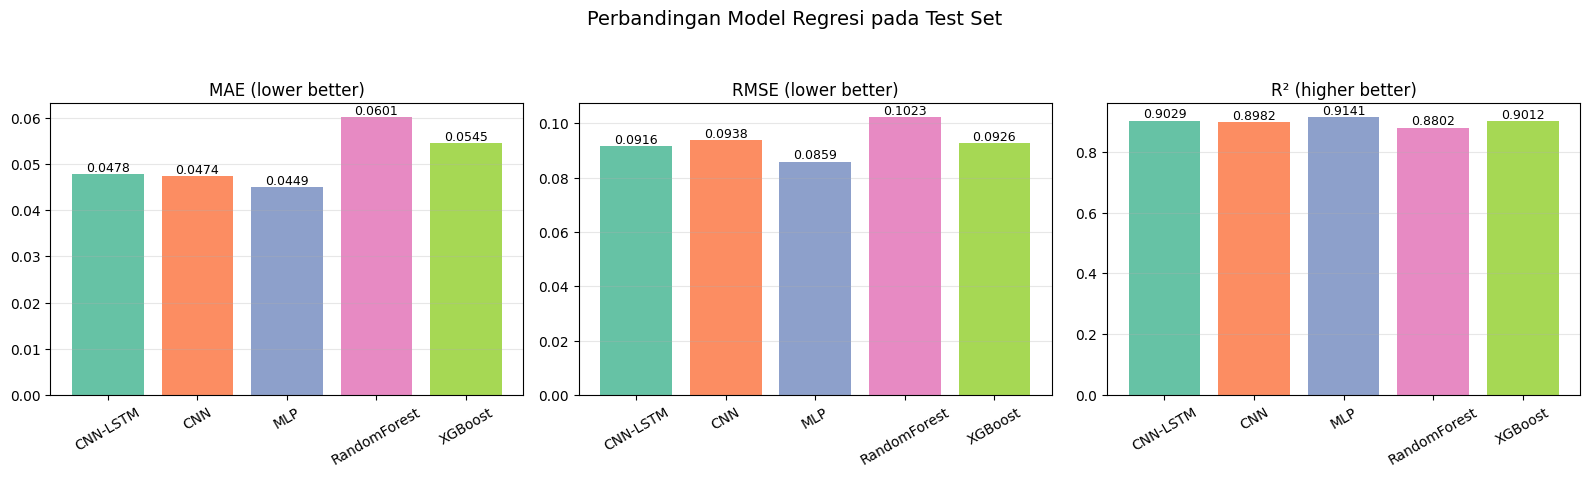

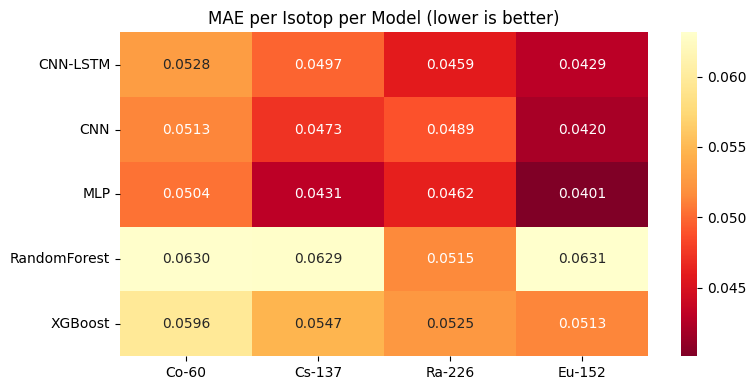

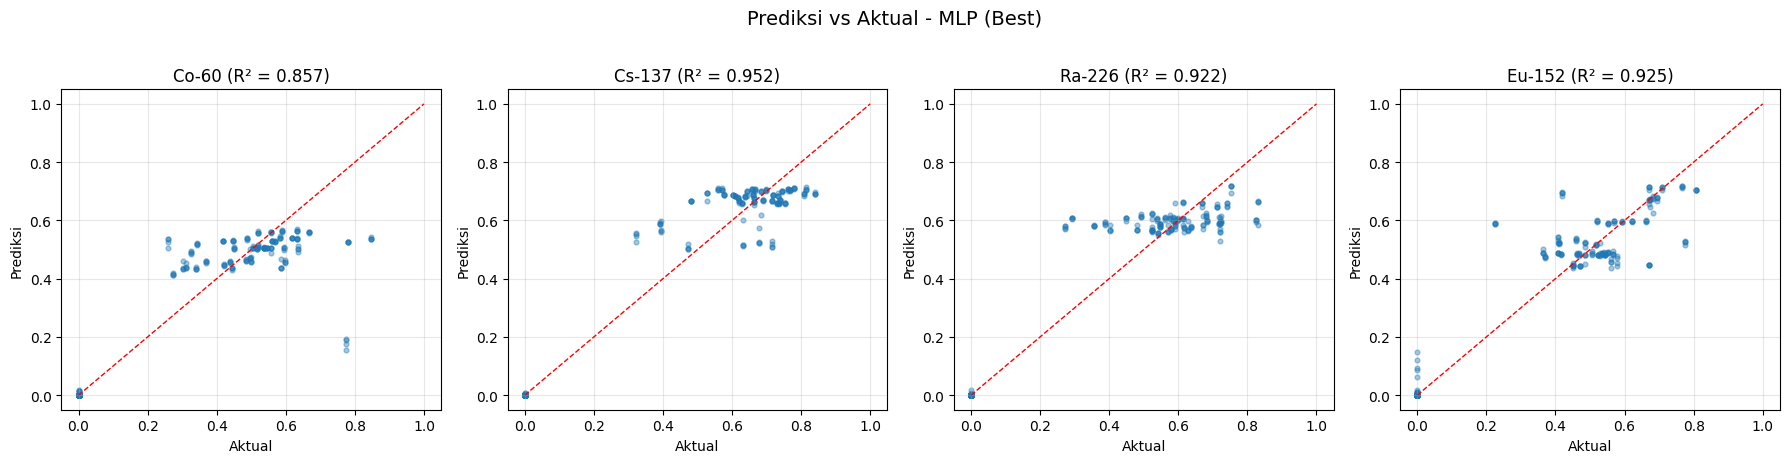

In [8]:
# (a) Perbandingan MAE / RMSE / R² across models
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric, title, lower_better in zip(axes, ['mae', 'rmse', 'r2'],
                                            ['MAE', 'RMSE', 'R²'], [True, True, False]):
    vals = [test_results[m][metric] for m in test_results]
    colors = sns.color_palette('Set2', len(test_results))
    bars = ax.bar(test_results.keys(), vals, color=colors)
    ax.set_title(f'{title} {"(lower better)" if lower_better else "(higher better)"}')
    ax.tick_params(axis='x', rotation=30)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.grid(alpha=0.3, axis='y')
plt.suptitle('Perbandingan Model Regresi pada Test Set', y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_regresi.png'), dpi=120, bbox_inches='tight')
plt.show()

# (b) MAE per isotop heatmap
fig, ax = plt.subplots(figsize=(8, 4))
mae_iso = pd.DataFrame({m: [test_results[m][f'mae_{iso}'] for iso in ISOTOP]
                         for m in test_results}, index=ISOTOP).T
sns.heatmap(mae_iso, annot=True, fmt='.4f', cmap='YlOrRd_r', ax=ax)
ax.set_title('MAE per Isotop per Model (lower is better)')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'mae_per_isotop.png'), dpi=120, bbox_inches='tight')
plt.show()

# (c) Scatter prediksi vs actual untuk model terbaik
best_model_name = df['mae'].idxmin()
best_pred = test_predictions[best_model_name]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, i, iso in zip(axes, range(4), ISOTOP):
    ax.scatter(y_test[:, i], best_pred[:, i], alpha=0.4, s=12)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Aktual'); ax.set_ylabel('Prediksi')
    ax.set_title(f'{iso} (R² = {test_results[best_model_name][f"r2_{iso}"]:.3f})')
    ax.grid(alpha=0.3)
plt.suptitle(f'Prediksi vs Aktual - {best_model_name} (Best)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'scatter_predict_actual.png'), dpi=120, bbox_inches='tight')
plt.show()

## 9. Ringkasan & Laporan

In [9]:
ranking = df['mae'].sort_values(ascending=True)
print('=== RANKING (by MAE test, lower is better) ===')
for i, (m, v) in enumerate(ranking.items(), 1):
    marker = '⭐' if i == 1 else '  '
    print(f'  {marker} #{i} {m:15s}: MAE={v:.4f}  RMSE={test_results[m]["rmse"]:.4f}  R²={test_results[m]["r2"]:.4f}')

best = ranking.index[0]
print(f'\nModel terbaik    : {best}')
print(f'Test MAE         : {ranking.iloc[0]:.4f}')
print(f'Test RMSE        : {test_results[best]["rmse"]:.4f}')
print(f'Test R²          : {test_results[best]["r2"]:.4f}')
print(f'\nBest hyperparams : {best_params[best]}')

with open(os.path.join(RESULTS_DIR, 'final_report_regresi.txt'), 'w') as f:
    f.write('=== LAPORAN REGRESI AKTIVITAS RADIONUKLIDA ===\n\n')
    f.write(f'Tanggal           : {time.strftime("%Y-%m-%d %H:%M")}\n')
    f.write(f'N_TRIALS per model: {N_TRIALS_PER_MODEL}\n\n')
    f.write('--- Test Set Metrics ---\n')
    f.write(df.round(4).to_string())
    f.write('\n\n--- Ranking (by MAE) ---\n')
    for i, (m, v) in enumerate(ranking.items(), 1):
        f.write(f'  #{i} {m}: MAE={v:.4f}\n')
    f.write(f'\nModel terbaik: {best}\n')
    f.write(f'\nBest hyperparameters:\n')
    for m, hp in best_params.items():
        f.write(f'  {m}: {hp}\n')

print('\nFinal report disimpan.')

=== RANKING (by MAE test, lower is better) ===
  ⭐ #1 MLP            : MAE=0.0449  RMSE=0.0859  R²=0.9141
     #2 CNN            : MAE=0.0474  RMSE=0.0938  R²=0.8982
     #3 CNN-LSTM       : MAE=0.0478  RMSE=0.0916  R²=0.9029
     #4 XGBoost        : MAE=0.0545  RMSE=0.0926  R²=0.9012
     #5 RandomForest   : MAE=0.0601  RMSE=0.1023  R²=0.8802

Model terbaik    : MLP
Test MAE         : 0.0449
Test RMSE        : 0.0859
Test R²          : 0.9141

Best hyperparams : {'n_layers': 4, 'h0': 512, 'h1': 512, 'h2': 512, 'h3': 512, 'dropout': 0.4253445738564908, 'lr': 0.0003070027358663033, 'batch_size': 64, 'optimizer': 'adam', 'loss_type': 'mae'}

Final report disimpan.


## 10. Analisis Residual, Scatter Semua Model, Distribusi Error

Scatter prediksi vs aktual untuk SEMUA model (bukan hanya yang terbaik), plus residual plot dan distribusi error per isotop.

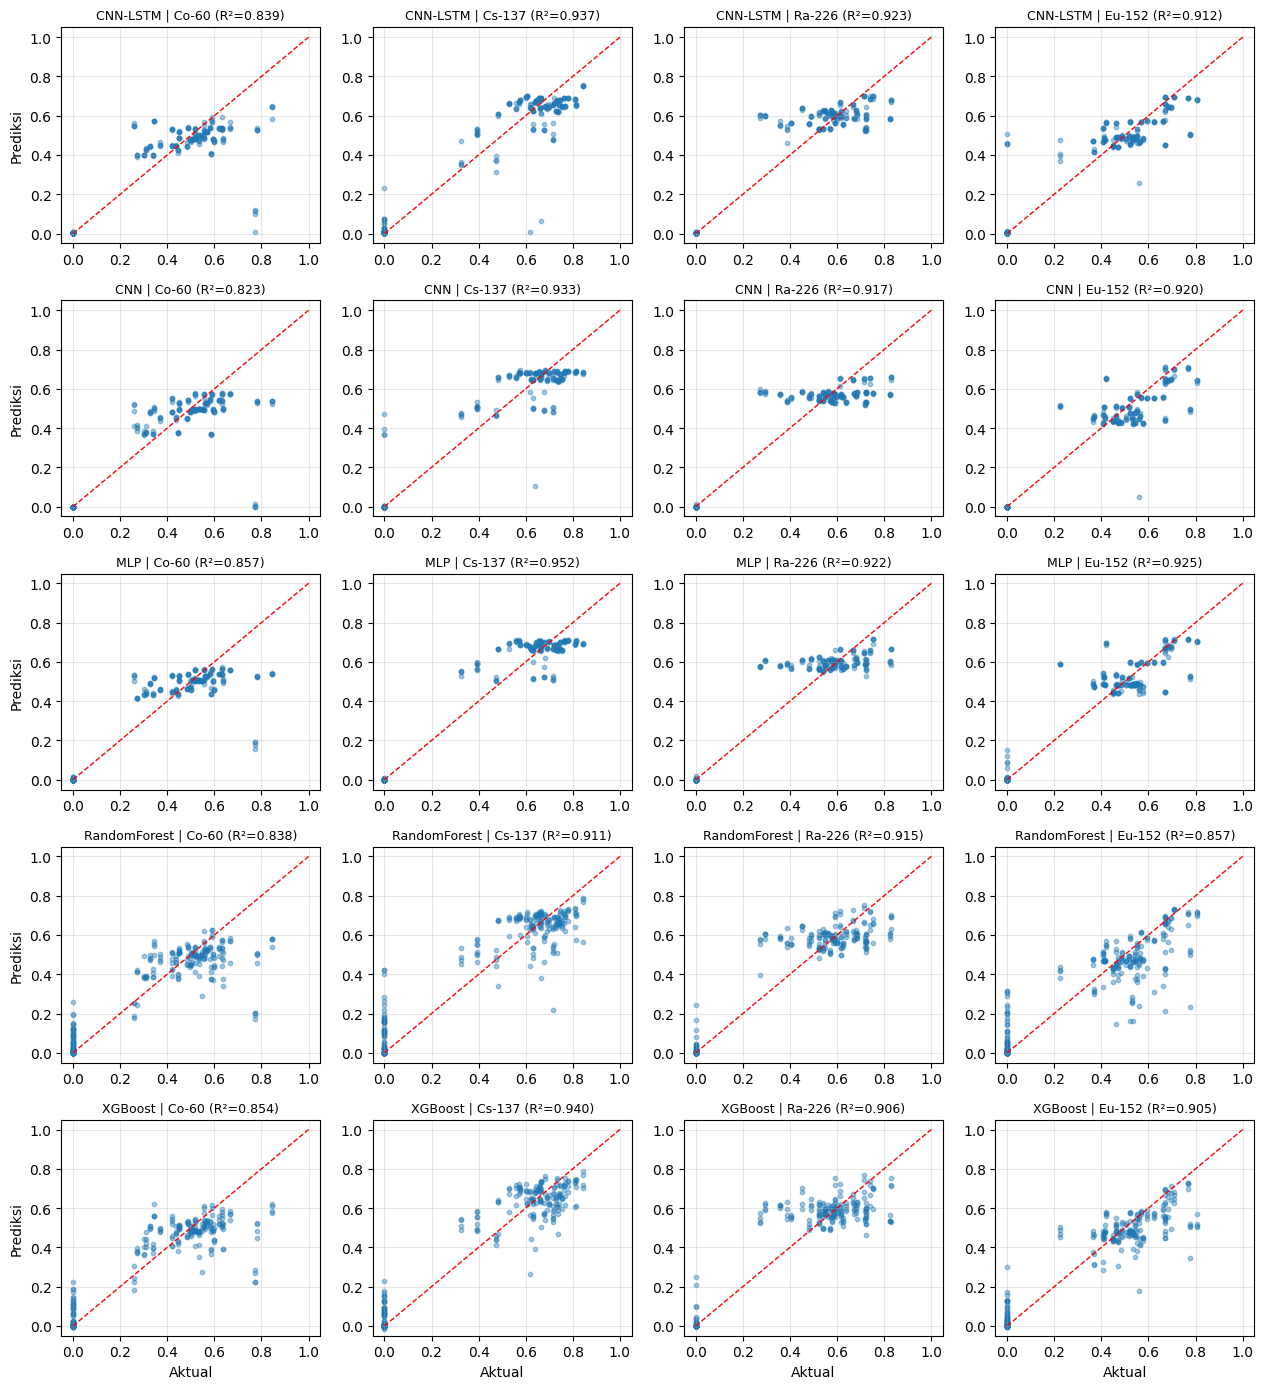

Model dengan MAE terendah: MLP (MAE=0.0449)


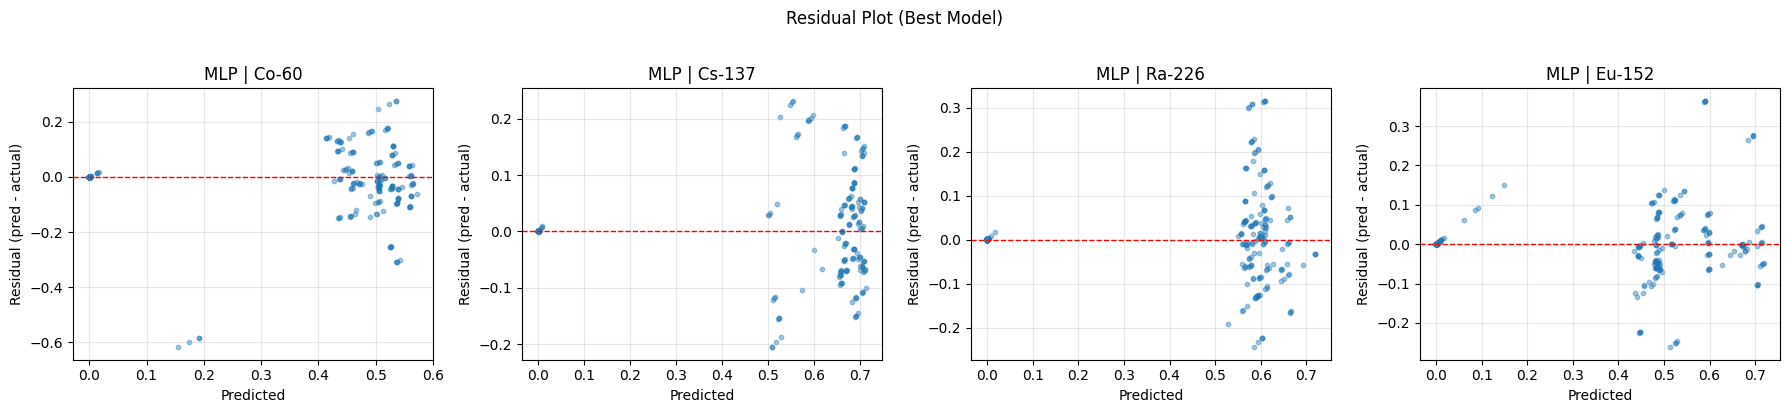

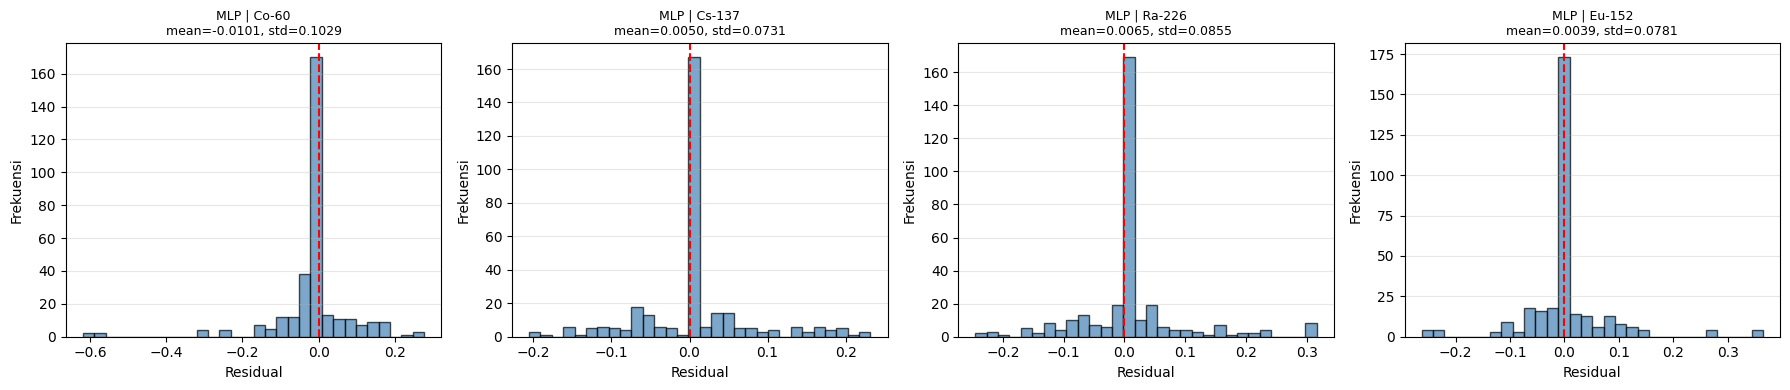

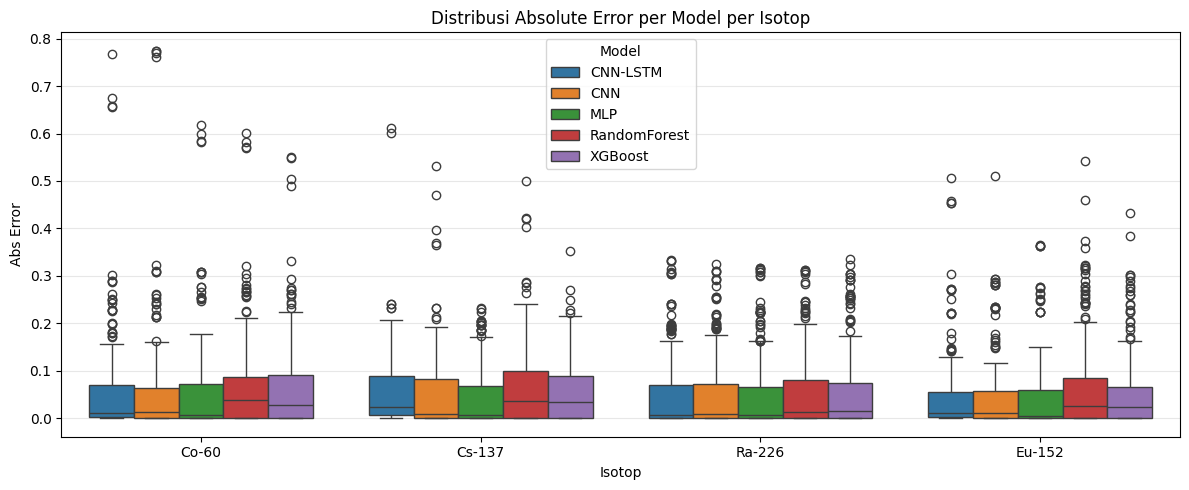

Analisis residual & error distribution disimpan.


In [10]:
preds_path = os.path.join(RESULTS_DIR, 'test_predictions_regresi.npz')
preds_data = np.load(preds_path)
y_true = preds_data['y_test']
model_names = [k for k in preds_data.files if k != 'y_test']
ISOTOP_STR = [str(s) for s in ISOTOP]
n_models = len(model_names); n_iso = len(ISOTOP_STR)

# === A. Scatter prediksi vs aktual: SEMUA model, per isotop ===
fig, axes = plt.subplots(n_models, n_iso, figsize=(3.2*n_iso, 2.8*n_models))
for i, m in enumerate(model_names):
    pred = preds_data[m]
    for j, iso in enumerate(ISOTOP_STR):
        ax = axes[i, j] if n_models > 1 else axes[j]
        r2 = r2_score(y_true[:, j], pred[:, j])
        ax.scatter(y_true[:, j], pred[:, j], alpha=0.4, s=10)
        ax.plot([0, 1], [0, 1], 'r--', lw=1)
        ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'{m} | {iso} (R²={r2:.3f})', fontsize=9)
        if i == n_models - 1: ax.set_xlabel('Aktual')
        if j == 0: ax.set_ylabel('Prediksi')
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'scatter_all_models.png'), dpi=120, bbox_inches='tight')
plt.show()

# === B. Residual plot model terbaik (residual vs predicted) ===
mae_per_model = {m: mean_absolute_error(y_true, preds_data[m]) for m in model_names}
best_m = min(mae_per_model, key=mae_per_model.get)
print(f'Model dengan MAE terendah: {best_m} (MAE={mae_per_model[best_m]:.4f})')
pred_best = preds_data[best_m]
residual = pred_best - y_true

fig, axes = plt.subplots(1, n_iso, figsize=(4.5*n_iso, 4))
for ax, j, iso in zip(axes, range(n_iso), ISOTOP_STR):
    ax.scatter(pred_best[:, j], residual[:, j], alpha=0.4, s=10)
    ax.axhline(0, color='r', ls='--', lw=1)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Residual (pred - actual)')
    ax.set_title(f'{best_m} | {iso}')
    ax.grid(alpha=0.3)
plt.suptitle('Residual Plot (Best Model)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'residual_plot.png'), dpi=120, bbox_inches='tight')
plt.show()

# === C. Histogram error per isotop ===
fig, axes = plt.subplots(1, n_iso, figsize=(4.5*n_iso, 4))
for ax, j, iso in zip(axes, range(n_iso), ISOTOP_STR):
    ax.hist(residual[:, j], bins=30, alpha=0.7, color='steelblue', edgecolor='k')
    ax.axvline(0, color='r', ls='--')
    ax.set_xlabel('Residual'); ax.set_ylabel('Frekuensi')
    ax.set_title(f'{best_m} | {iso}\nmean={residual[:,j].mean():.4f}, std={residual[:,j].std():.4f}',
                  fontsize=9)
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'residual_histogram.png'), dpi=120, bbox_inches='tight')
plt.show()

# === D. Boxplot absolute error: semua model x isotop ===
records = []
for m in model_names:
    p = preds_data[m]
    for j, iso in enumerate(ISOTOP_STR):
        for err in np.abs(p[:, j] - y_true[:, j]):
            records.append({'Model': m, 'Isotop': iso, 'Abs Error': err})
df_err = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_err, x='Isotop', y='Abs Error', hue='Model', ax=ax)
ax.set_title('Distribusi Absolute Error per Model per Isotop')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'error_boxplot.png'), dpi=120, bbox_inches='tight')
plt.show()

print('Analisis residual & error distribution disimpan.')

## 11. Training Loss Curves

Re-train DL singkat untuk merekam train/val loss per epoch. Wajib untuk laporan: menunjukkan konvergensi dan tidak overfitting.

Merekam training history untuk model DL...
  CNN-LSTM...
  CNN...
  MLP...


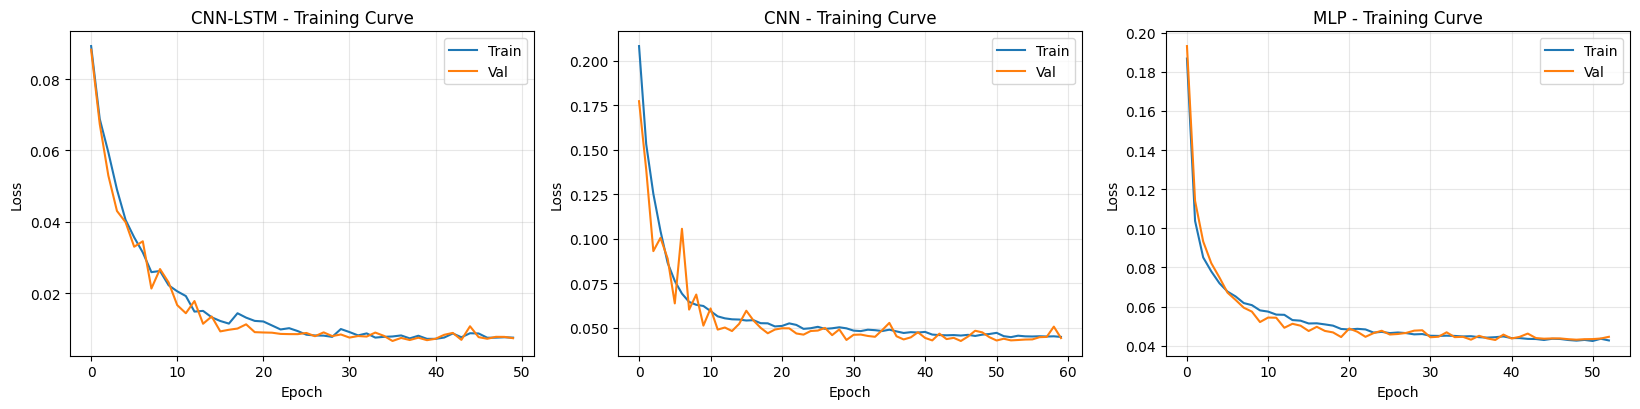

Training curves disimpan.


In [11]:
def train_with_history_reg(model_class, hp, X_tr, y_tr, X_va, y_va,
                            max_epochs=MAX_EPOCHS*2, patience=PATIENCE*2,
                            arch_filter_fn=None):
    if arch_filter_fn:
        arch_hp = arch_filter_fn(hp)
    else:
        arch_keys = [k for k in hp if k not in {'lr', 'batch_size', 'optimizer', 'loss_type'}]
        arch_hp = {k: hp[k] for k in arch_keys}
    model = model_class(**arch_hp).to(DEVICE)

    Xt = torch.tensor(X_tr, dtype=torch.float32); yt = torch.tensor(y_tr, dtype=torch.float32)
    Xv = torch.tensor(X_va, dtype=torch.float32).to(DEVICE); yv = torch.tensor(y_va, dtype=torch.float32).to(DEVICE)
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=hp['batch_size'], shuffle=True)

    if hp['optimizer'] == 'adam':
        opt = optim.Adam(model.parameters(), lr=hp['lr'])
    else:
        opt = optim.AdamW(model.parameters(), lr=hp['lr'], weight_decay=1e-4)

    loss_fn = nn.L1Loss() if hp.get('loss_type') == 'mae' else nn.MSELoss()
    tr_hist, va_hist = [], []
    best_val = float('inf'); wait = 0

    for epoch in range(max_epochs):
        model.train()
        ep_loss, n = 0.0, 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
            ep_loss += loss.item() * len(xb); n += len(xb)
        model.eval()
        with torch.no_grad():
            vl = loss_fn(model(Xv), yv).item()
        tr_hist.append(ep_loss / n); va_hist.append(vl)
        if vl < best_val - 1e-6:
            best_val = vl; wait = 0
        else:
            wait += 1
            if wait >= patience: break
    return tr_hist, va_hist


if 'best_params' not in globals():
    with open(os.path.join(RESULTS_DIR, 'best_hyperparams_regresi.json')) as f:
        best_params = json.load(f)['best_params']

data = np.load(DATA_NPZ, allow_pickle=True)
X_full = np.concatenate([data['X_train'], data['X_val']], axis=0)
y_full = np.concatenate([data['y_reg_train'], data['y_reg_val']], axis=0)
rng = np.random.RandomState(SEED)
idx = rng.permutation(len(X_full))
sp = int(len(X_full) * 0.9)
tr_i, va_i = idx[:sp], idx[sp:]

histories = {}
print('Merekam training history untuk model DL...')

for name, cls in [('CNN-LSTM', CNN_LSTM_Reg), ('CNN', CNN_Reg)]:
    print(f'  {name}...')
    th, vh = train_with_history_reg(cls, best_params[name],
                                      X_full[tr_i], y_full[tr_i], X_full[va_i], y_full[va_i])
    histories[name] = {'train': th, 'val': vh}

print(f'  MLP...')
mlp_hp = best_params['MLP']
n_layers = mlp_hp['n_layers']
hidden = [mlp_hp[f'h{i}'] for i in range(n_layers)]
th, vh = train_with_history_reg(MLP_Reg, mlp_hp,
                                  X_full[tr_i], y_full[tr_i], X_full[va_i], y_full[va_i],
                                  arch_filter_fn=lambda hp: {'hidden_layers': hidden, 'dropout': hp['dropout']})
histories['MLP'] = {'train': th, 'val': vh}

fig, axes = plt.subplots(1, len(histories), figsize=(5.5*len(histories), 4.2))
for ax, (name, h) in zip(axes, histories.items()):
    ax.plot(h['train'], label='Train', color='tab:blue')
    ax.plot(h['val'],   label='Val',   color='tab:orange')
    ax.set_title(f'{name} - Training Curve')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

with open(os.path.join(RESULTS_DIR, 'training_history.json'), 'w') as f:
    json.dump(histories, f, indent=2)
print('Training curves disimpan.')

## 12. Analisis Tuning Optuna

Visualisasi hasil hyperparameter tuning: optimization history, parameter importance, parallel coordinate.


--- CNN-LSTM (100 trials, best MAE=0.0499) ---


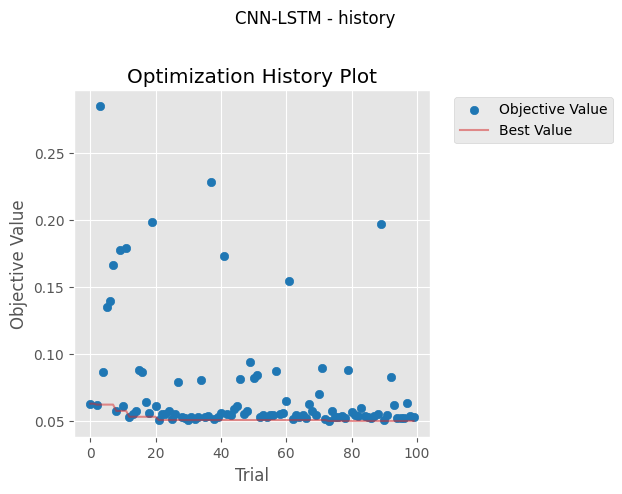

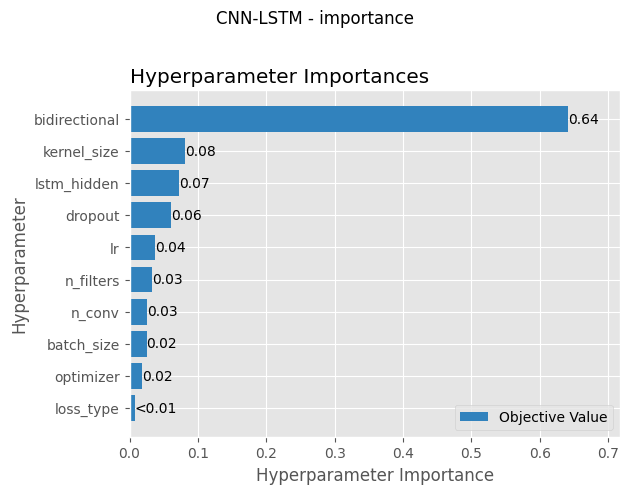

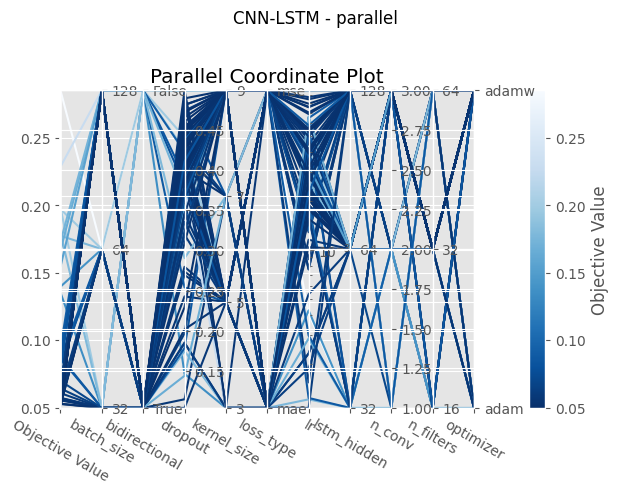


--- CNN (100 trials, best MAE=0.0473) ---


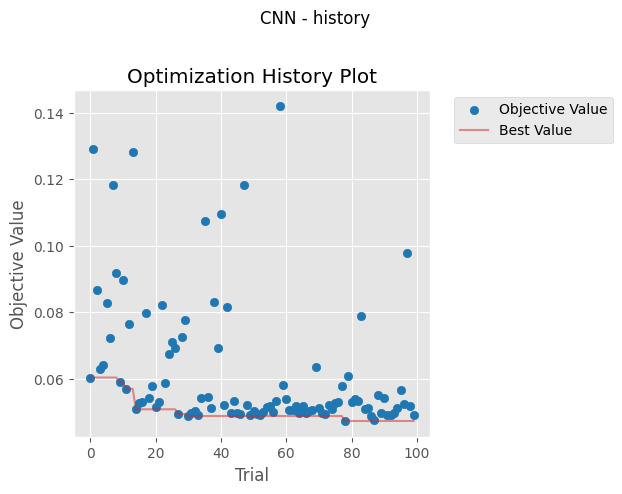

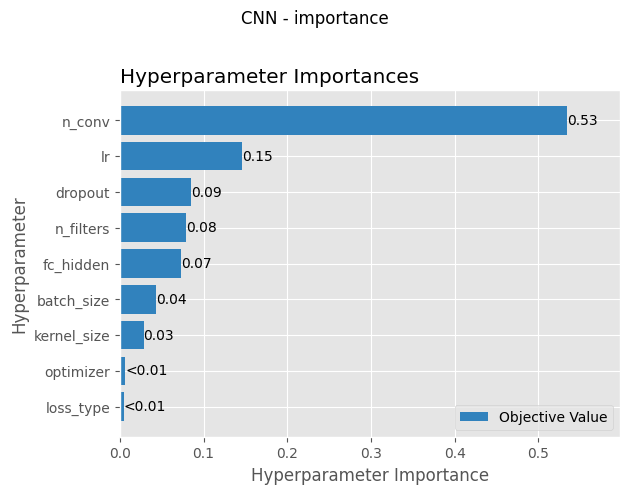

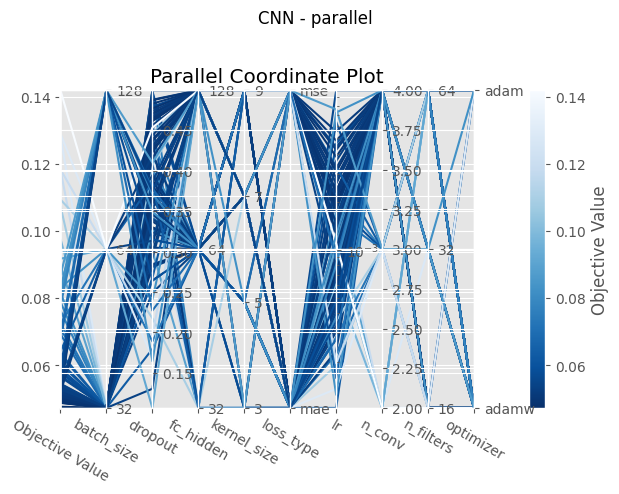


--- MLP (100 trials, best MAE=0.0457) ---


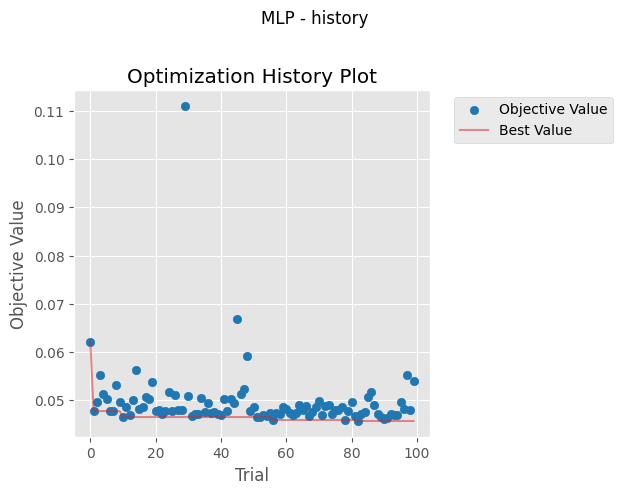

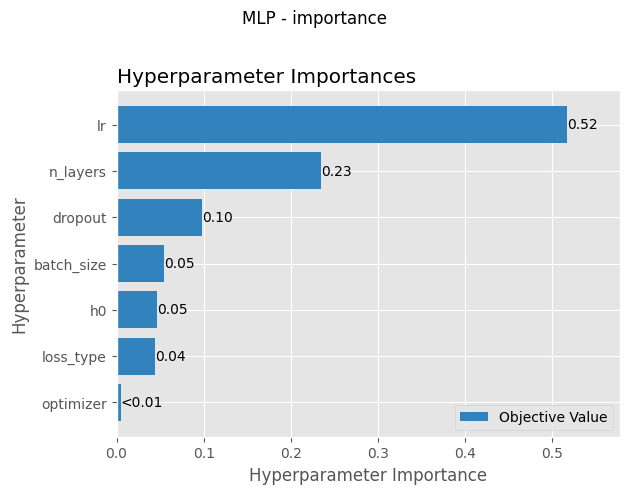

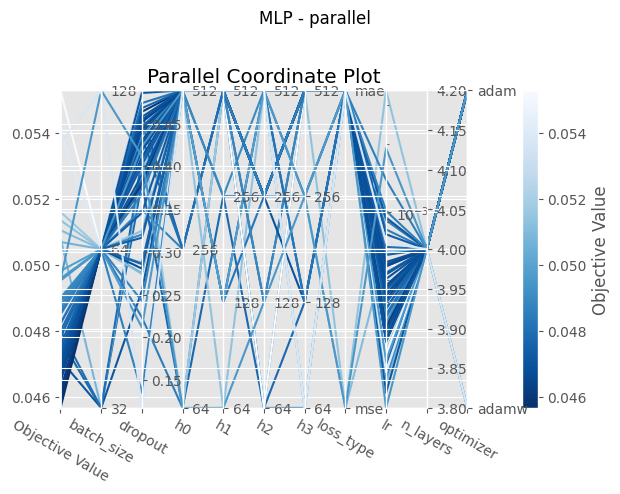


--- RandomForest (100 trials, best MAE=0.0606) ---


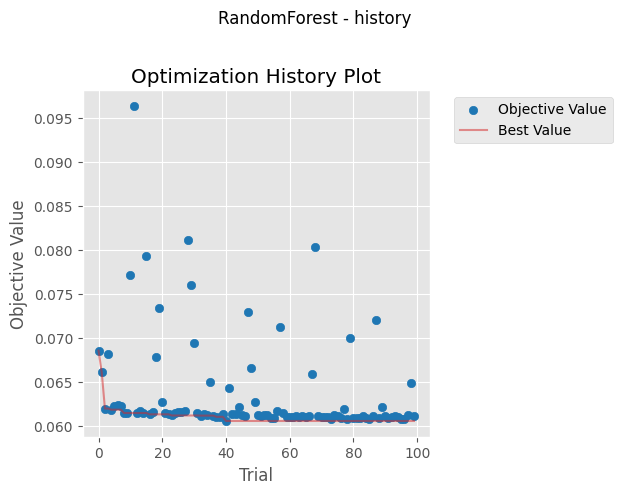

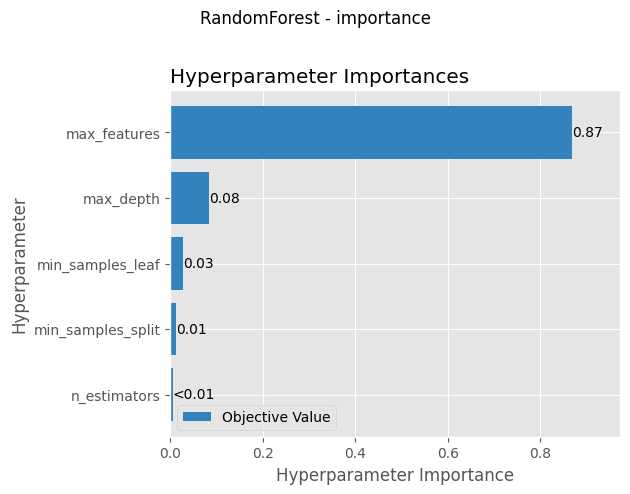

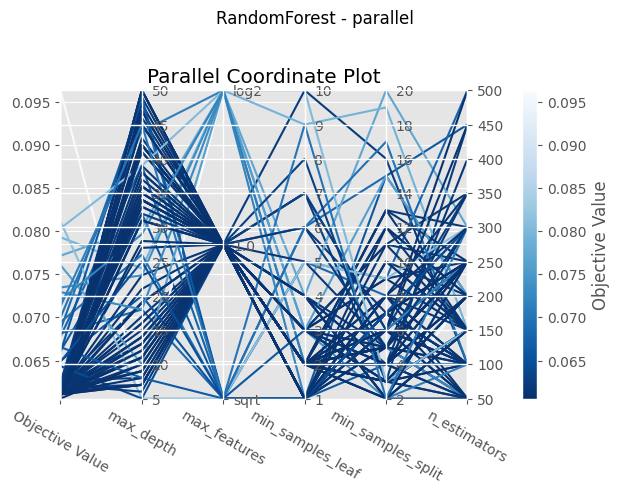


--- XGBoost (100 trials, best MAE=0.0568) ---


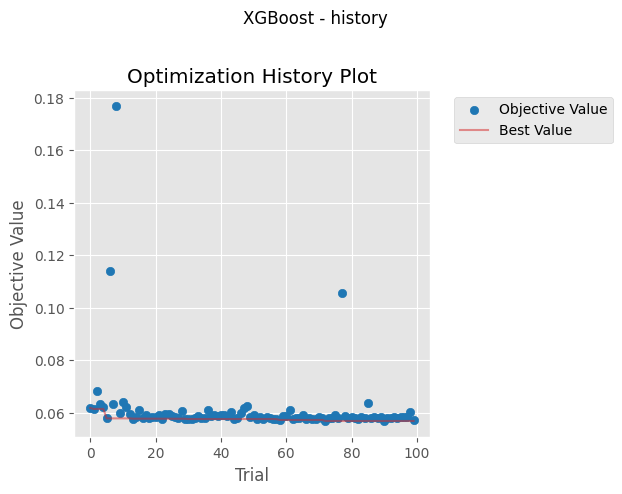

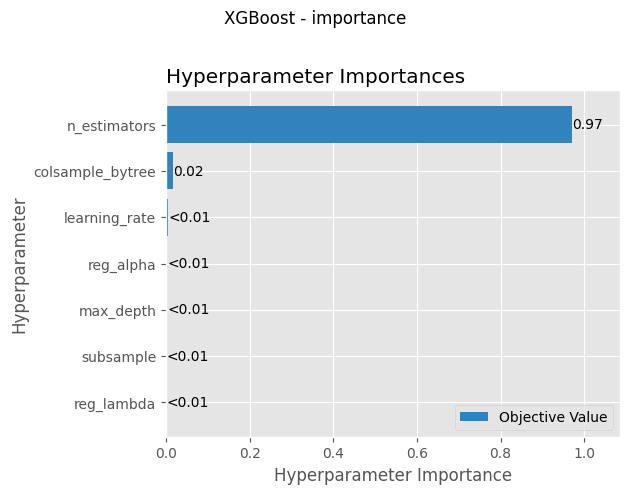

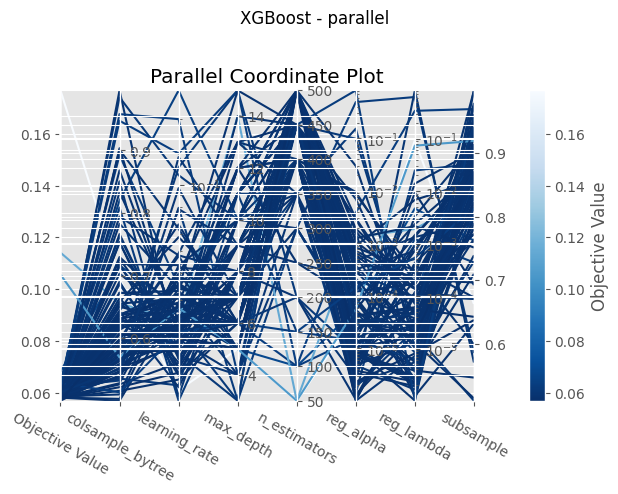


Optuna tuning analysis disimpan.


In [12]:
import optuna.visualization.matplotlib as ovm

for model_name in ['CNN-LSTM', 'CNN', 'MLP', 'RandomForest', 'XGBoost']:
    try:
        study = optuna.load_study(study_name=f'reg_{model_name}', storage=STORAGE)
    except KeyError:
        print(f'  Study reg_{model_name} tidak ditemukan, skip.')
        continue
    print(f'\n--- {model_name} ({len(study.trials)} trials, best MAE={study.best_value:.4f}) ---')

    for plot_fn, suffix in [
        (ovm.plot_optimization_history, 'history'),
        (ovm.plot_param_importances,    'importance'),
        (ovm.plot_parallel_coordinate,  'parallel'),
    ]:
        try:
            ax = plot_fn(study)
            fig = ax.figure
            fig.suptitle(f'{model_name} - {suffix}', y=1.02)
            fig.tight_layout()
            fig.savefig(os.path.join(RESULTS_DIR, f'optuna_{model_name}_{suffix}.png'),
                         dpi=120, bbox_inches='tight')
            plt.show()
        except Exception as e:
            print(f'    skip {suffix}: {e}')
            plt.close('all')

print('\nOptuna tuning analysis disimpan.')

## 13. Reproducibility & Inference Benchmark

Tabel versi package, hardware, jumlah parameter & waktu inference per model.

In [13]:
import platform, sklearn

env_info = {
    'Python'        : platform.python_version(),
    'OS'            : f'{platform.system()} {platform.release()}',
    'CPU cores'     : os.cpu_count(),
    'NumPy'         : np.__version__,
    'pandas'        : pd.__version__,
    'matplotlib'    : plt.matplotlib.__version__,
    'PyTorch'       : torch.__version__,
    'CUDA'          : torch.version.cuda if torch.cuda.is_available() else 'N/A',
    'GPU'           : torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A',
    'scikit-learn'  : sklearn.__version__,
    'XGBoost'       : xgb.__version__,
    'Optuna'        : optuna.__version__,
    'Random seed'   : SEED,
}
print('=== Environment ===')
for k, v in env_info.items():
    print(f'  {k:<14s}: {v}')
with open(os.path.join(RESULTS_DIR, 'environment.json'), 'w') as f:
    json.dump({k: str(v) for k, v in env_info.items()}, f, indent=2)

data = np.load(DATA_NPZ, allow_pickle=True)
X_test_arr = data['X_test']
n_test = len(X_test_arr)

if 'best_params' not in globals():
    with open(os.path.join(RESULTS_DIR, 'best_hyperparams_regresi.json')) as f:
        best_params = json.load(f)['best_params']

bench = {}

# --- DL: CNN-LSTM, CNN ---
for name, cls, ckpt in [('CNN-LSTM', CNN_LSTM_Reg, 'cnn_lstm_reg.pt'),
                         ('CNN', CNN_Reg, 'cnn_reg.pt')]:
    hp = best_params[name]
    arch_keys = [k for k in hp if k not in {'lr', 'batch_size', 'optimizer', 'loss_type'}]
    arch_hp = {k: hp[k] for k in arch_keys}
    model = cls(**arch_hp).to(DEVICE)
    model.load_state_dict(torch.load(os.path.join(MODELS_DIR, ckpt), map_location=DEVICE))
    model.eval()
    n_params = sum(p.numel() for p in model.parameters())
    xw = torch.randn(1, 1024).to(DEVICE)
    with torch.no_grad():
        for _ in range(10): _ = model(xw)
    xb = torch.tensor(X_test_arr, dtype=torch.float32).to(DEVICE)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        for i in range(n_test): _ = model(xb[i:i+1])
    if torch.cuda.is_available(): torch.cuda.synchronize()
    dt_single = (time.time() - t0) / n_test * 1000
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        _ = model(xb)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    dt_batch = (time.time() - t0) / n_test * 1000
    bench[name] = {
        '#Params/Complexity': n_params,
        'Latency single (ms)': round(dt_single, 4),
        'Latency batch (ms/sample)': round(dt_batch, 4),
    }

# --- MLP ---
mlp_hp = best_params['MLP']
n_layers = mlp_hp['n_layers']
hidden = [mlp_hp[f'h{i}'] for i in range(n_layers)]
model = MLP_Reg(hidden_layers=hidden, dropout=mlp_hp['dropout']).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'mlp_reg.pt'), map_location=DEVICE))
model.eval()
n_params = sum(p.numel() for p in model.parameters())
xw = torch.randn(1, 1024).to(DEVICE)
with torch.no_grad():
    for _ in range(10): _ = model(xw)
xb = torch.tensor(X_test_arr, dtype=torch.float32).to(DEVICE)
if torch.cuda.is_available(): torch.cuda.synchronize()
t0 = time.time()
with torch.no_grad():
    for i in range(n_test): _ = model(xb[i:i+1])
if torch.cuda.is_available(): torch.cuda.synchronize()
dt_single = (time.time() - t0) / n_test * 1000
if torch.cuda.is_available(): torch.cuda.synchronize()
t0 = time.time()
with torch.no_grad():
    _ = model(xb)
if torch.cuda.is_available(): torch.cuda.synchronize()
dt_batch = (time.time() - t0) / n_test * 1000
bench['MLP'] = {
    '#Params/Complexity': n_params,
    'Latency single (ms)': round(dt_single, 4),
    'Latency batch (ms/sample)': round(dt_batch, 4),
}

# --- Tree-based ---
for name, fname in [('RandomForest', 'rf_reg.pkl'), ('XGBoost', 'xgb_reg.pkl')]:
    with open(os.path.join(MODELS_DIR, fname), 'rb') as f:
        model = pickle.load(f)
    if name == 'RandomForest':
        n_params = sum(est.tree_.node_count for est in model.estimators_)
    else:
        n_params = sum(int(clf.get_booster().num_boosted_rounds()) for clf in model.estimators_)
    t0 = time.time()
    for i in range(n_test):
        _ = model.predict(X_test_arr[i:i+1])
    dt_single = (time.time() - t0) / n_test * 1000
    t0 = time.time()
    _ = model.predict(X_test_arr)
    dt_batch = (time.time() - t0) / n_test * 1000
    bench[name] = {
        '#Params/Complexity': n_params,
        'Latency single (ms)': round(dt_single, 4),
        'Latency batch (ms/sample)': round(dt_batch, 4),
    }

df_bench = pd.DataFrame(bench).T
print('\n=== Benchmark ===')
print(df_bench.to_string())
df_bench.to_csv(os.path.join(RESULTS_DIR, 'benchmark_regresi.csv'))
print('\nBenchmark & environment info disimpan.')

=== Environment ===
  Python        : 3.12.4
  OS            : Windows 11
  CPU cores     : 20
  NumPy         : 2.1.0
  pandas        : 2.2.2
  matplotlib    : 3.9.2
  PyTorch       : 2.6.0+cu124
  CUDA          : 12.4
  GPU           : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  scikit-learn  : 1.6.1
  XGBoost       : 3.2.0
  Optuna        : 4.8.0
  Random seed   : 42

=== Benchmark ===
              #Params/Complexity  Latency single (ms)  Latency batch (ms/sample)
CNN-LSTM                358340.0               1.2578                     0.0886
CNN                     114660.0               0.9170                     0.0177
MLP                    1318916.0               0.6761                     0.0000
RandomForest             25230.0              24.4744                     0.0797
XGBoost                   1800.0               2.9731                     0.0277

Benchmark & environment info disimpan.


## 14. Export Hyperparameter Tuning Trials ke Excel

Export semua trial Optuna dari 5 model ke file Excel berstyle:
- **Sheet `Summary`** - best per model, di-rank dari yang terbaik.
- **Sheet `All_Trials_Ranking`** - SEMUA trial dari semua model, diurutkan dari Val MAE terbaik (terendah) ke terburuk.
- **Satu sheet per model** - SEMUA trial dengan kolom lengkap (Run, Trial, hyperparameter, Val MAE, Duration, Rank).

Styling: header berwarna, *color scale* pada kolom metric, *freeze panes*, baris terbaik di-highlight hijau, auto-width.

In [14]:
import optuna
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.utils import get_column_letter

# ====== Konfigurasi ======
STUDY_PREFIX = "reg_"
METRIC_NAME  = "MAE"
DIRECTION    = "minimize"        # 'maximize' atau 'minimize'
MODEL_NAMES  = ['CNN-LSTM', 'CNN', 'MLP', 'RandomForest', 'XGBoost']
RUN_SIZE     = 10                      # 1 Run = 10 Trial (seperti tabel referensi)
OUT_XLSX     = os.path.join(RESULTS_DIR, "tuning_trials_regresi.xlsx")
METRIC_COL   = f"Val {METRIC_NAME}"
ASC          = (DIRECTION == "minimize")

# ====== Load Optuna studies ======
studies = {}
for name in MODEL_NAMES:
    try:
        studies[name] = optuna.load_study(study_name=f"{STUDY_PREFIX}{name}", storage=STORAGE)
        print(f"  Loaded {STUDY_PREFIX}{name}: {len(studies[name].trials)} trials")
    except KeyError:
        print(f"  WARNING: study {STUDY_PREFIX}{name} tidak ditemukan, skip.")

# ====== Convert ke DataFrame per model ======
trial_dfs = {}
for model_name, study in studies.items():
    rows = []
    for t in sorted(study.trials, key=lambda x: x.number):
        if t.value is None or t.state.name != "COMPLETE":
            continue
        params = {k: (str(v) if isinstance(v, (list, tuple)) else v) for k, v in t.params.items()}
        duration = None
        if t.datetime_complete and t.datetime_start:
            duration = round((t.datetime_complete - t.datetime_start).total_seconds(), 2)
        rows.append({
            "Run":    t.number // RUN_SIZE + 1,
            "Trial":  t.number + 1,
            **params,
            METRIC_COL:     round(float(t.value), 6),
            "Duration (s)": duration,
        })
    df = pd.DataFrame(rows)
    df["Rank in Model"] = df[METRIC_COL].rank(ascending=ASC, method="min").astype(int)
    trial_dfs[model_name] = df

# ====== Gabungan semua trial untuk ranking sheet ======
all_rows = []
for model_name, df in trial_dfs.items():
    for _, r in df.iterrows():
        all_rows.append({"Model": model_name, **r.to_dict()})
df_all = pd.DataFrame(all_rows)
df_all["Global Rank"]   = df_all[METRIC_COL].rank(ascending=ASC, method="min").astype(int)
df_all_sorted = df_all.sort_values(METRIC_COL, ascending=ASC).reset_index(drop=True)

# ====== Summary: best per model ======
summary_rows = []
for model_name, df in trial_dfs.items():
    best_idx = df[METRIC_COL].idxmin() if ASC else df[METRIC_COL].idxmax()
    best = df.loc[best_idx]
    summary_rows.append({
        "Model":             model_name,
        "N Trials":          len(df),
        f"Best {METRIC_COL}": best[METRIC_COL],
        "Best Trial #":       int(best["Trial"]),
        "Best Run":           int(best["Run"]),
        f"Mean {METRIC_COL}": round(df[METRIC_COL].mean(), 6),
        f"Std {METRIC_COL}":  round(df[METRIC_COL].std(),  6),
    })
df_summary = pd.DataFrame(summary_rows).sort_values(
    f"Best {METRIC_COL}", ascending=ASC
).reset_index(drop=True)
df_summary.insert(0, "Rank", range(1, len(df_summary) + 1))


# ====== Helper styling Excel ======
def _style_sheet(ws, df, metric_col, direction, freeze="A2"):
    header_font = Font(bold=True, color="FFFFFF", size=11, name="Calibri")
    header_fill = PatternFill("solid", fgColor="1F4E78")
    best_fill   = PatternFill("solid", fgColor="C6EFCE")
    thin_side   = Side(style="thin", color="D9D9D9")
    border      = Border(left=thin_side, right=thin_side, top=thin_side, bottom=thin_side)
    align       = Alignment(horizontal="center", vertical="center")

    # Header
    for c, col in enumerate(df.columns, 1):
        cell = ws.cell(1, c, str(col))
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = align
        cell.border = border
    ws.row_dimensions[1].height = 26

    # Data
    for r in range(len(df)):
        for c, col in enumerate(df.columns, 1):
            v = df.iloc[r, c - 1]
            if hasattr(v, "item"):
                v = v.item()
            if isinstance(v, float) and pd.isna(v):
                v = None
            cell = ws.cell(r + 2, c, v)
            cell.border = border
            cell.alignment = align
            if isinstance(v, float):
                cell.number_format = "0.000000" if (abs(v) < 0.01 and v != 0) else "0.0000"

    # Highlight best row (by metric)
    if metric_col in df.columns and len(df) > 0:
        idx = df[metric_col].idxmin() if direction == "minimize" else df[metric_col].idxmax()
        best_excel_row = df.index.get_loc(idx) + 2
        for c in range(1, len(df.columns) + 1):
            cell = ws.cell(best_excel_row, c)
            cell.fill = best_fill
            cell.font = Font(bold=True)

    # Color-scale conditional formatting pada metric column
    if metric_col in df.columns and len(df) > 1:
        c = list(df.columns).index(metric_col) + 1
        col_letter = get_column_letter(c)
        last = len(df) + 1
        if direction == "maximize":
            rule = ColorScaleRule(
                start_type="min", start_color="F8696B",
                mid_type="percentile", mid_value=50, mid_color="FFEB84",
                end_type="max", end_color="63BE7B"
            )
        else:
            rule = ColorScaleRule(
                start_type="min", start_color="63BE7B",
                mid_type="percentile", mid_value=50, mid_color="FFEB84",
                end_type="max", end_color="F8696B"
            )
        ws.conditional_formatting.add(f"{col_letter}2:{col_letter}{last}", rule)

    # Freeze + auto-width
    ws.freeze_panes = freeze
    for c, col in enumerate(df.columns, 1):
        lengths = [len(str(col))]
        for r in range(min(len(df), 200)):
            try:
                lengths.append(len(str(df.iloc[r, c - 1])))
            except Exception:
                pass
        ws.column_dimensions[get_column_letter(c)].width = min(max(max(lengths) + 2, 10), 28)


# ====== Tulis Excel ======
wb = Workbook()
wb.remove(wb.active)

# Sheet 1: Summary (best per model)
ws = wb.create_sheet("Summary")
_style_sheet(ws, df_summary, f"Best {METRIC_COL}", DIRECTION)

# Sheet 2: All_Trials_Ranking
ws = wb.create_sheet("All_Trials_Ranking")
front = ["Global Rank", "Model", "Run", "Trial", METRIC_COL, "Duration (s)", "Rank in Model"]
front = [c for c in front if c in df_all_sorted.columns]
other = [c for c in df_all_sorted.columns if c not in front]
_style_sheet(ws, df_all_sorted[front + other], METRIC_COL, DIRECTION)

# Sheet per model
for model_name, df in trial_dfs.items():
    ws = wb.create_sheet(model_name)
    front = ["Run", "Trial", "Rank in Model", METRIC_COL, "Duration (s)"]
    front = [c for c in front if c in df.columns]
    other = [c for c in df.columns if c not in front]
    _style_sheet(ws, df[front + other], METRIC_COL, DIRECTION)

wb.save(OUT_XLSX)
print(f"\nExcel disimpan: {OUT_XLSX}")
print(f"  Sheets: Summary, All_Trials_Ranking, {', '.join(trial_dfs.keys())}")

print("\n=== Summary: Best per Model ===")
print(df_summary.to_string(index=False))

print(f"\n=== Top 10 Trials Overall (direction={DIRECTION}) ===")
preview = ["Global Rank", "Model", "Run", "Trial", METRIC_COL]
preview = [c for c in preview if c in df_all_sorted.columns]
print(df_all_sorted.head(10)[preview].to_string(index=False))


  Loaded reg_CNN-LSTM: 100 trials
  Loaded reg_CNN: 100 trials
  Loaded reg_MLP: 100 trials
  Loaded reg_RandomForest: 100 trials
  Loaded reg_XGBoost: 100 trials

Excel disimpan: C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)\results_regresi\tuning_trials_regresi.xlsx
  Sheets: Summary, All_Trials_Ranking, CNN-LSTM, CNN, MLP, RandomForest, XGBoost

=== Summary: Best per Model ===
 Rank        Model  N Trials  Best Val MAE  Best Trial #  Best Run  Mean Val MAE  Std Val MAE
    1          MLP       100      0.045664            83         9      0.049637     0.007003
    2          CNN       100      0.047325            79         8      0.062220     0.020223
    3     CNN-LSTM        99      0.049851            74         8      0.073577     0.043281
    4      XGBoost       100      0.056825            73         8      0.061117     0.013844
    5 RandomForest       100      0.060601            41         5      0.063615     0.005632

=== Top 10 Trials Overall (direction

## 15. Training Curves Detail: Loss + MAE + R^2 per Epoch

Re-train model dengan tracking loss + MAE + R^2 per epoch (DL), RMSE + MAE per boosting round (XGBoost), dan OOB R^2 vs jumlah pohon (RandomForest).

Merekam history (loss, MAE, R^2) untuk model DL regresi...
  CNN-LSTM ...
  CNN ...
  MLP ...


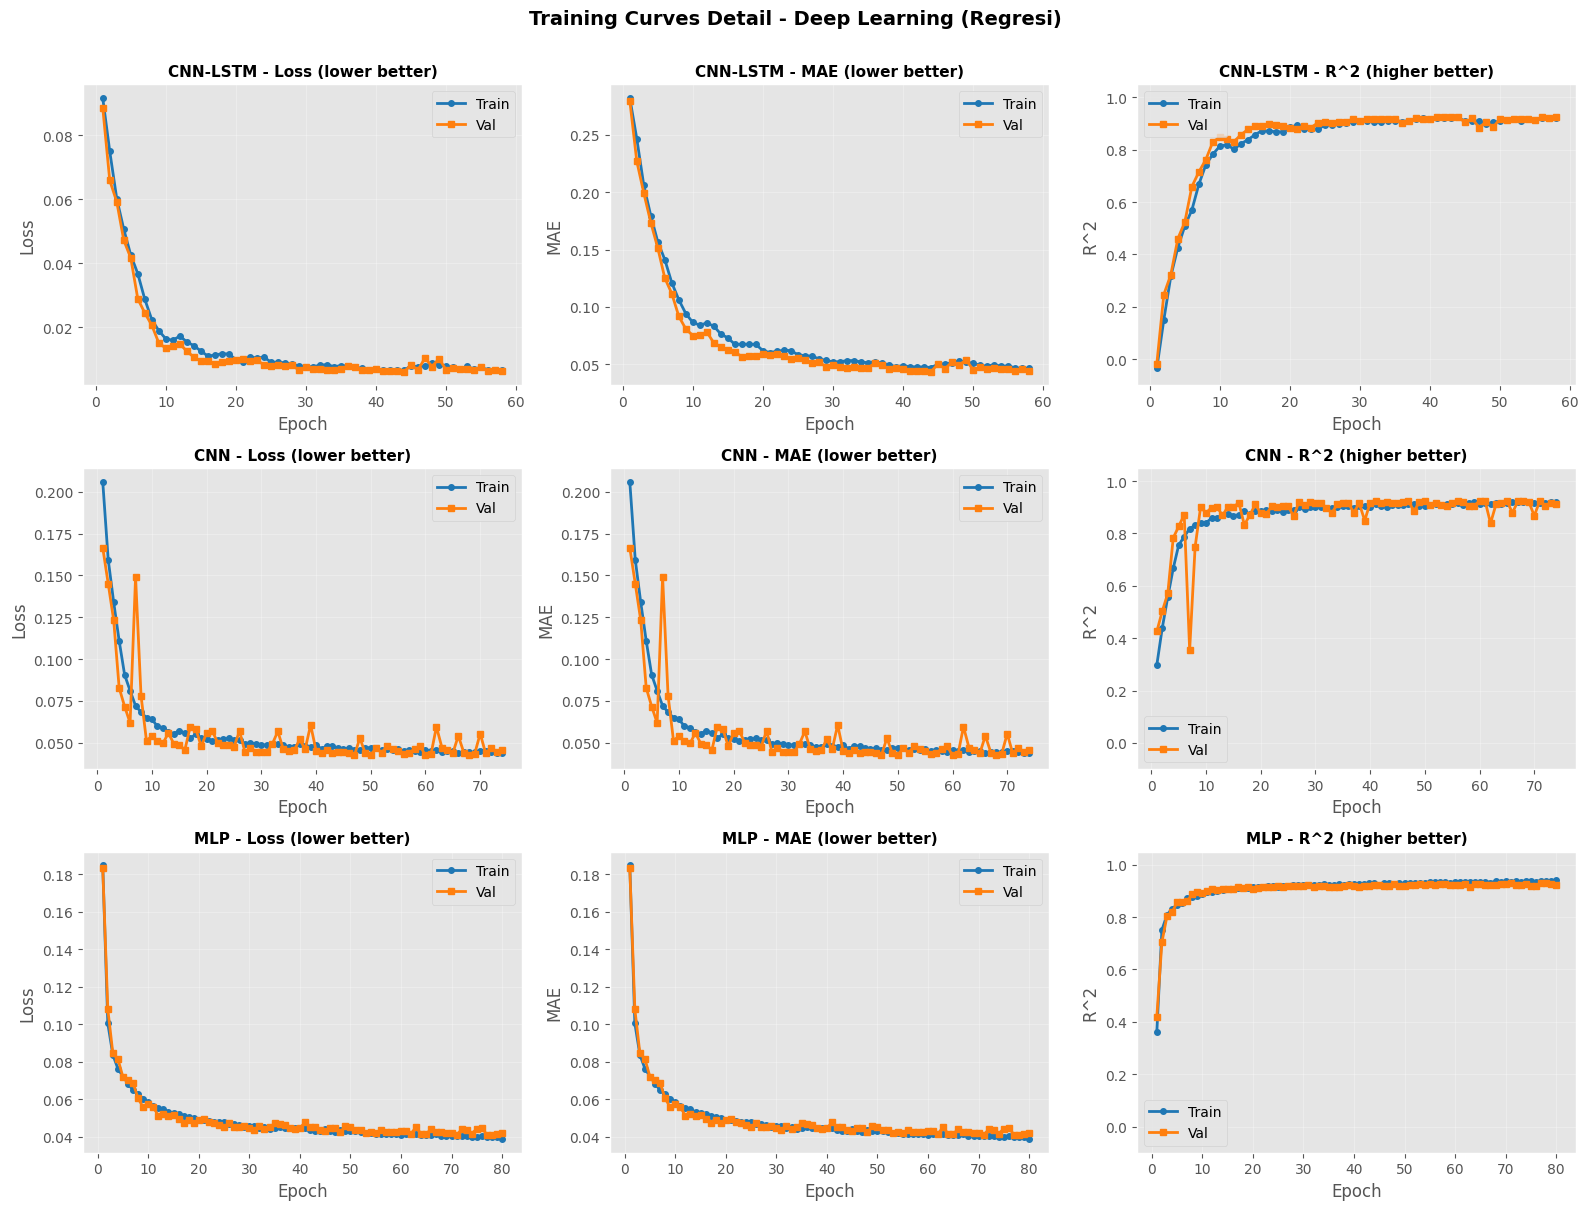


Merekam history XGBoost regresi per boosting round (per isotop)...


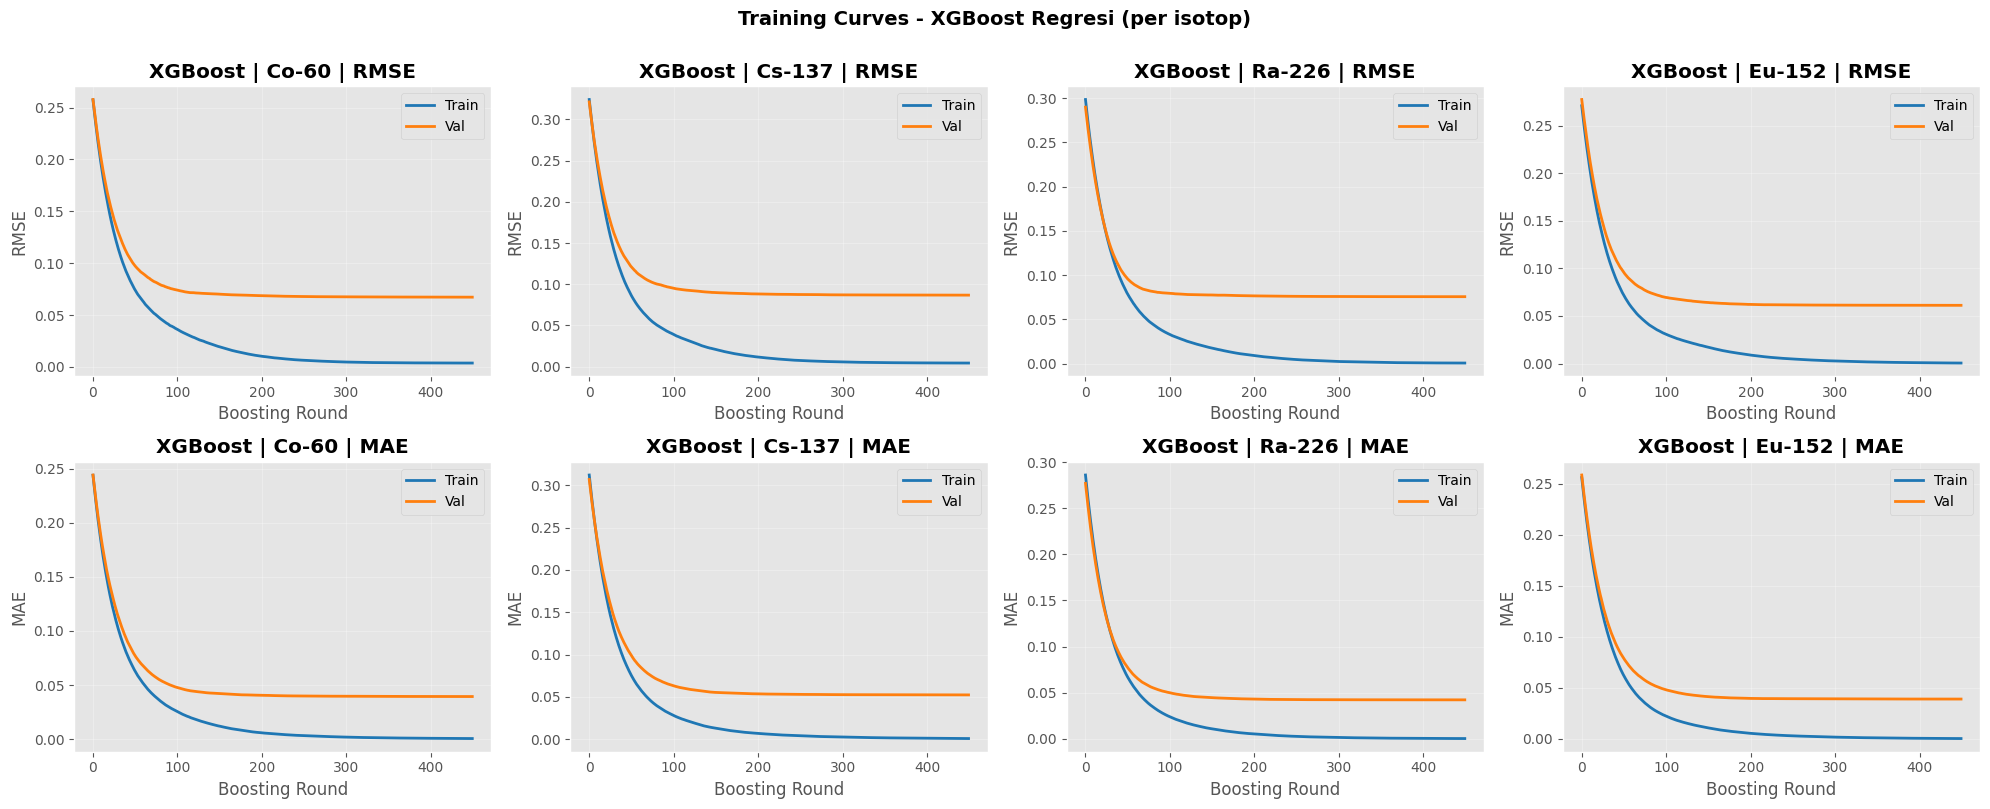


Merekam OOB R^2 RandomForest vs jumlah pohon (per isotop)...


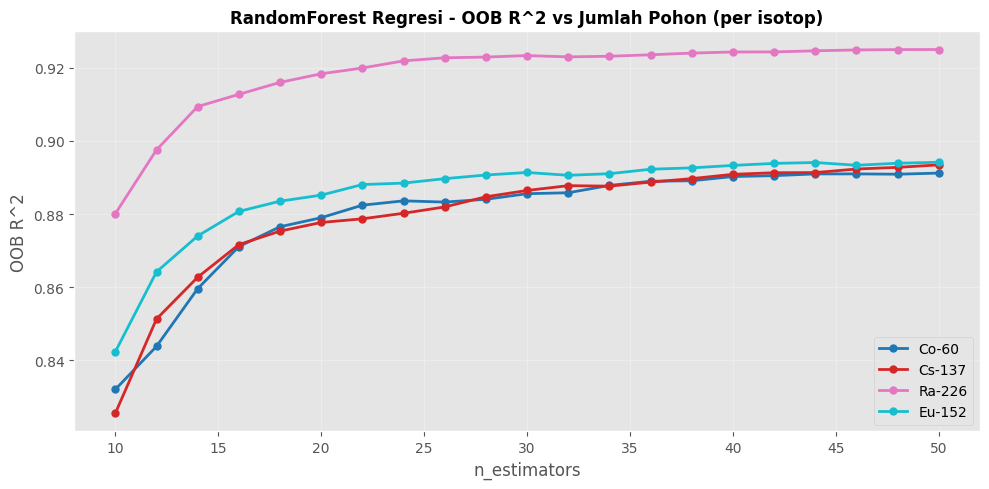


Semua training curves disimpan ke C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)\results_regresi


In [15]:
# Training curves detail untuk model regresi.
# NOTE: cell ini re-train model DL utk merekam loss+MAE+R^2 per epoch.
#       Total waktu ~10-15 menit di GPU RTX 3050.

if 'best_params' not in globals():
    with open(os.path.join(RESULTS_DIR, 'best_hyperparams_regresi.json')) as f:
        best_params = json.load(f)['best_params']

data = np.load(DATA_NPZ, allow_pickle=True)
X_full = np.concatenate([data['X_train'], data['X_val']], axis=0)
y_full = np.concatenate([data['y_reg_train'], data['y_reg_val']], axis=0).astype(np.float32)
rng = np.random.RandomState(SEED)
idx = rng.permutation(len(X_full))
sp = int(len(X_full) * 0.9)
tr_i, va_i = idx[:sp], idx[sp:]


def train_full_history_reg(model_class, hp, max_epochs=MAX_EPOCHS*2, patience=PATIENCE*2,
                            arch_filter_fn=None):
    """Rekam train/val loss + MAE + R^2 per epoch."""
    if arch_filter_fn:
        arch_hp = arch_filter_fn(hp)
    else:
        skip = {'lr', 'batch_size', 'optimizer', 'loss_type', 'n_layers'}
        arch_keys = [k for k in hp if k not in skip and not k.startswith('h')]
        arch_hp = {k: hp[k] for k in arch_keys}
    model = model_class(**arch_hp).to(DEVICE)

    Xtr = torch.tensor(X_full[tr_i], dtype=torch.float32)
    ytr = torch.tensor(y_full[tr_i], dtype=torch.float32)
    Xva = torch.tensor(X_full[va_i], dtype=torch.float32).to(DEVICE)
    yva = torch.tensor(y_full[va_i], dtype=torch.float32).to(DEVICE)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=hp['batch_size'], shuffle=True)

    opt = (optim.Adam(model.parameters(), lr=hp['lr']) if hp['optimizer'] == 'adam'
           else optim.AdamW(model.parameters(), lr=hp['lr'], weight_decay=1e-4))
    loss_fn = nn.L1Loss() if hp.get('loss_type') == 'mae' else nn.MSELoss()

    H = {k: [] for k in ['train_loss','val_loss','train_mae','val_mae','train_r2','val_r2']}
    best_val, wait = float('inf'), 0
    for epoch in range(max_epochs):
        model.train()
        ep_loss, n = 0.0, 0
        tr_preds, tr_ys = [], []
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward(); opt.step()
            ep_loss += loss.item() * len(xb); n += len(xb)
            tr_preds.append(pred.detach()); tr_ys.append(yb.detach())

        with torch.no_grad():
            tp = torch.cat(tr_preds).cpu().numpy()
            ty = torch.cat(tr_ys).cpu().numpy()
            H['train_loss'].append(ep_loss / n)
            H['train_mae'].append(float(mean_absolute_error(ty, tp)))
            H['train_r2'].append(float(r2_score(ty, tp, multioutput='uniform_average')))

            model.eval()
            vp = model(Xva)
            vl = loss_fn(vp, yva).item()
            vp_np = vp.cpu().numpy()
            vy_np = yva.cpu().numpy()
            H['val_loss'].append(vl)
            H['val_mae'].append(float(mean_absolute_error(vy_np, vp_np)))
            H['val_r2'].append(float(r2_score(vy_np, vp_np, multioutput='uniform_average')))

        if vl < best_val - 1e-6:
            best_val, wait = vl, 0
        else:
            wait += 1
            if wait >= patience:
                break
    return H


dl_histories = {}
print('Merekam history (loss, MAE, R^2) untuk model DL regresi...')
for name, cls in [('CNN-LSTM', CNN_LSTM_Reg), ('CNN', CNN_Reg)]:
    print(f'  {name} ...')
    dl_histories[name] = train_full_history_reg(cls, best_params[name])

# MLP butuh handling khusus (n_layers + h0..h3)
mlp_hp   = best_params['MLP']
n_layers = mlp_hp['n_layers']
hidden   = [mlp_hp[f'h{i}'] for i in range(n_layers)]
print('  MLP ...')
dl_histories['MLP'] = train_full_history_reg(
    MLP_Reg, mlp_hp,
    arch_filter_fn=lambda hp: {'hidden_layers': hidden, 'dropout': hp['dropout']}
)

# Plot DL: rows=model, cols=[Loss, MAE, R^2]
fig, axes = plt.subplots(len(dl_histories), 3, figsize=(16, 4.0 * len(dl_histories)))
for i, (name, H) in enumerate(dl_histories.items()):
    epochs = range(1, len(H['train_loss']) + 1)
    for j, (key, ylabel, ylim, lower) in enumerate([
        ('loss', 'Loss',  None,           True),
        ('mae',  'MAE',   None,           True),
        ('r2',   'R^2',   (-0.1, 1.05),   False),
    ]):
        ax = axes[i, j] if len(dl_histories) > 1 else axes[j]
        ax.plot(epochs, H[f'train_{key}'], 'o-', label='Train', color='#1f77b4', ms=4, lw=2)
        ax.plot(epochs, H[f'val_{key}'],   's-', label='Val',   color='#ff7f0e', ms=4, lw=2)
        suffix = '(lower better)' if lower else '(higher better)'
        ax.set_title(f'{name} - {ylabel} {suffix}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        if ylim: ax.set_ylim(*ylim)
        ax.legend(loc='best'); ax.grid(alpha=0.3)
plt.suptitle('Training Curves Detail - Deep Learning (Regresi)',
             y=1.005, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves_detailed.png'),
            dpi=120, bbox_inches='tight')
plt.show()

with open(os.path.join(RESULTS_DIR, 'training_history_detailed.json'), 'w') as f:
    json.dump(dl_histories, f, indent=2)


# ====== XGBoost regresi: RMSE + MAE per boosting round (per isotop) ======
print('\nMerekam history XGBoost regresi per boosting round (per isotop)...')
xgb_hp = dict(best_params['XGBoost'])
xgb_histories = {}
for i, iso in enumerate([str(s) for s in ISOTOP]):
    base = xgb.XGBRegressor(**xgb_hp, random_state=SEED, n_jobs=-1,
                             eval_metric=['rmse', 'mae'], verbosity=0)
    base.fit(X_full[tr_i], y_full[tr_i][:, i],
             eval_set=[(X_full[tr_i], y_full[tr_i][:, i]),
                       (X_full[va_i], y_full[va_i][:, i])],
             verbose=False)
    xgb_histories[iso] = base.evals_result()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, (iso, res) in enumerate(xgb_histories.items()):
    ax = axes[0, i]
    ax.plot(res['validation_0']['rmse'], label='Train', color='#1f77b4', lw=2)
    ax.plot(res['validation_1']['rmse'], label='Val',   color='#ff7f0e', lw=2)
    ax.set_title(f'XGBoost | {iso} | RMSE', fontweight='bold')
    ax.set_xlabel('Boosting Round'); ax.set_ylabel('RMSE')
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1, i]
    ax.plot(res['validation_0']['mae'], label='Train', color='#1f77b4', lw=2)
    ax.plot(res['validation_1']['mae'], label='Val',   color='#ff7f0e', lw=2)
    ax.set_title(f'XGBoost | {iso} | MAE', fontweight='bold')
    ax.set_xlabel('Boosting Round'); ax.set_ylabel('MAE')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Training Curves - XGBoost Regresi (per isotop)',
             y=1.005, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves_xgboost.png'),
            dpi=120, bbox_inches='tight')
plt.show()


# ====== RandomForest regresi: OOB R^2 vs jumlah pohon (per isotop) ======
print('\nMerekam OOB R^2 RandomForest vs jumlah pohon (per isotop)...')
from sklearn.ensemble import RandomForestRegressor as _RFR
rf_hp = dict(best_params['RandomForest'])
max_n = rf_hp.pop('n_estimators')
n_estimators_list = list(range(10, max_n + 1, max(1, max_n // 20)))

oob_scores = {}
for i, iso in enumerate([str(s) for s in ISOTOP]):
    rf = _RFR(**rf_hp, n_estimators=n_estimators_list[0], oob_score=True,
              warm_start=True, random_state=SEED, n_jobs=-1, bootstrap=True)
    scores = []
    for n_tree in n_estimators_list:
        rf.set_params(n_estimators=n_tree)
        rf.fit(X_full[tr_i], y_full[tr_i][:, i])
        scores.append(rf.oob_score_)
    oob_scores[iso] = scores

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(oob_scores)))
for (iso, scores), c in zip(oob_scores.items(), colors):
    ax.plot(n_estimators_list, scores, 'o-', label=iso, lw=2, ms=5, color=c)
ax.set_title('RandomForest Regresi - OOB R^2 vs Jumlah Pohon (per isotop)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('n_estimators'); ax.set_ylabel('OOB R^2')
ax.legend(loc='best'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves_rf.png'),
            dpi=120, bbox_inches='tight')
plt.show()

print('\nSemua training curves disimpan ke', RESULTS_DIR)
